# Üç Makineli Üretim Hattının Ayrık Olay Simülasyonu ve Q-Learning ile Duruma Bağlı Makine Hız/Yönlendirme Kontrolü




## Proje Yol Haritası

1. **Veri Keşfi ve İstatistiksel Dağılım Çıkarımı**
2. Üç Makineli SimPy DES Modeli
3. Baseline Performans Metrikleri
4. Yıllık Ufuk, Dinamik Talep ve Makine Zaman Muhasebesi
5. RL: SimPy Hattının İçine Gömülü Q-Learning ile Hız/Yönlendirme/Bakım Kararı
6. Sonuçlar ve Değerlendirme



## 1. Veri Keşfi ve İstatistiksel Dağılım Çıkarımı



In [ ]:
import json
import os
import time
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib as mpl


CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
SURFACE, INK, INK_SEC, INK_MUTED, GRID, BASELINE = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7")

def apply_style():
    mpl.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": BASELINE, "axes.labelcolor": INK_SEC, "text.color": INK,
        "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "grid.color": GRID,
        "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
        "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
        "grid.linewidth": 0.8, "axes.axisbelow": True, "legend.frameon": False,
    })

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title: ax.set_title(title, loc="left", pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.7)
    ax.grid(axis="x", visible=False)
    return ax

apply_style()
pd.set_option('display.max_columns', None)


try:
    import simpy  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "simpy"], check=True)
    import simpy  # noqa: F401

try:
    import gymnasium  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gymnasium"], check=True)
    import gymnasium  # noqa: F401


DATA_PATH = "data/hybrid_manufacturing_categorical.csv"
if not os.path.exists(DATA_PATH):
    candidates = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    if candidates:
        DATA_PATH = candidates[0]
    else:
        try:
            from google.colab import files
            print("CSV dosyasi bulunamadi -> 'hybrid_manufacturing_categorical.csv' dosyasini secin:")
            uploaded = files.upload()
            DATA_PATH = list(uploaded.keys())[0]
        except ImportError:
            raise FileNotFoundError(
                "hybrid_manufacturing_categorical.csv bulunamadi. Dosyayi notebook ile "
                "ayni klasore (veya data/ alt klasorune) koyun."
            )
print("Kullanilan veri dosyasi:", DATA_PATH)

CSV dosyasi bulunamadi -> 'hybrid_manufacturing_categorical.csv' dosyasini secin:


Saving hybrid_manufacturing_categorical.csv to hybrid_manufacturing_categorical.csv
Kullanilan veri dosyasi: hybrid_manufacturing_categorical.csv


### 1.1 Veri Setine Genel Bakış

1000 iş kaydı, 5 makine (M01-M05), 5 operasyon tipi (Lathe, Grinding, Milling, Additive,
Drilling). `Actual_Start`/`Actual_End` alanlarında 129 eksik değer var bunlar
`Job_Status == 'Failed'` olan işlere karşılık geliyor: iş arızalanıp tamamlanamadığı için
gerçekleşen zaman hiç kaydedilmemiş

In [ ]:
df = pd.read_csv(DATA_PATH)
for c in ["Scheduled_Start", "Scheduled_End", "Actual_Start", "Actual_End"]:
    df[c] = pd.to_datetime(df[c])

print("Boyut:", df.shape)
df.head()

Boyut: (1000, 13)


,Job_ID,Machine_ID,Operation_Type,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Job_Status,Optimization_Category
0,J001,M01,Grinding,3.17,76,11.42,96,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,Completed,Moderate Efficiency
1,J002,M01,Grinding,3.35,79,6.61,84,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,Delayed,Low Efficiency
2,J003,M04,Additive,2.29,56,11.11,92,2023-03-18 08:20:00,2023-03-18 09:16:00,NaT,NaT,Failed,Low Efficiency
3,J004,M04,Grinding,1.76,106,12.50,95,2023-03-18 08:30:00,2023-03-18 10:16:00,2023-03-18 08:35:00,2023-03-18 10:21:00,Completed,Moderate Efficiency
4,J005,M01,Lathe,1.90,46,8.13,88,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,Completed,High Efficiency


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Job_ID,1000,1000,J1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Machine_ID,1000,5,M01,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Operation_Type,1000,5,Lathe,212,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Material_Used,1000.0,NaN,NaN,NaN,3.02648,1.01,2.04,3.08,4.0425,5.0,1.148139
Processing_Time,1000.0,NaN,NaN,NaN,71.384,20.0,48.0,72.0,96.0,120.0,28.48438
Energy_Consumption,1000.0,NaN,NaN,NaN,8.52134,2.01,5.3975,8.56,11.6725,14.98,3.669941
Machine_Availability,1000.0,NaN,NaN,NaN,89.163,80.0,84.0,89.0,94.0,99.0,5.757567
Scheduled_Start,1000,NaN,NaN,NaN,2023-03-21 19:15:00,2023-03-18 08:00:00,2023-03-20 01:37:30,2023-03-21 19:15:00,2023-03-23 12:52:30,2023-03-25 06:30:00,NaN
Scheduled_End,1000,NaN,NaN,NaN,2023-03-21 20:26:23.040000,2023-03-18 09:16:00,2023-03-20 02:27:45,2023-03-21 20:18:00,2023-03-23 14:05:30,2023-03-25 08:21:00,NaN
Actual_Start,871,NaN,NaN,NaN,2023-03-21 18:59:49.047072512,2023-03-18 08:05:00,2023-03-20 01:41:30,2023-03-21 17:52:00,2023-03-23 12:54:30,2023-03-25 06:29:00,NaN


In [ ]:
missing = df.isna().sum()
failed_missing = df.loc[df['Job_Status']=='Failed', ['Actual_Start','Actual_End']].isna().sum()
print("Eksik değerler:\n", missing[missing>0])
print("\nFailed işlerde eksik Actual_Start/End:\n", failed_missing)

Eksik değerler:
 Actual_Start    129
Actual_End      129
dtype: int64

Failed işlerde eksik Actual_Start/End:
 Actual_Start    129
Actual_End      129
dtype: int64


### 1.2 İşlem Süresi Dağılımı (`Processing_Time`)

Operasyon tipine göre işlem süresinin farklı olup olmadığına baktık. `Processing_Time` sadece
101 farklı tam sayı değeri alıyor (20'den 120'ye) — yani aslında **ayrık** bir değişken. Sürekli
bir Uniform dağılımı varsayan Kolmogorov-Smirnov testi burada yaklaşık bir sonuç veriyor;
ayrık yapıya daha uygun bir **ki-kare uygunluk testi** de ekliyoruz.

In [ ]:
df.groupby('Operation_Type')['Processing_Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Operation_Type,,,,,,,,
Additive,190.0,70.610526,29.457994,20.0,45.5,70.0,98.75,120.0
Drilling,189.0,71.470899,27.858981,21.0,50.0,76.0,94.00,120.0
Grinding,208.0,73.365385,29.288357,20.0,50.0,74.5,100.25,120.0
Lathe,212.0,71.169811,28.797206,20.0,46.0,72.0,97.00,120.0
Milling,201.0,70.208955,27.098452,21.0,47.0,71.0,93.00,120.0


Min=20, max=120, ortalama≈71.4, std≈28.5 değerleri **Uniform(20, 120)** dağılımının
teorik değerleriyle (ortalama=70, std=28.87) çok yakın. İki farklı testle kontrol ediyoruz:
Kolmogorov-Smirnov (sürekli yaklaşıklama) ve ayrık uniform için ki-kare uygunluk testi.

KS testi (sürekli yaklaşıklama, Uniform(20,120)): statistic=0.0410, p=0.0674
Ki-kare uygunluk testi (ayrık Uniform 20-120): chi2=98.678, p=0.5186
-> Her iki test de p > 0.05: Uniform(20,120) dk hipotezi reddedilemiyor (veri bu dağılımla tutarlı).


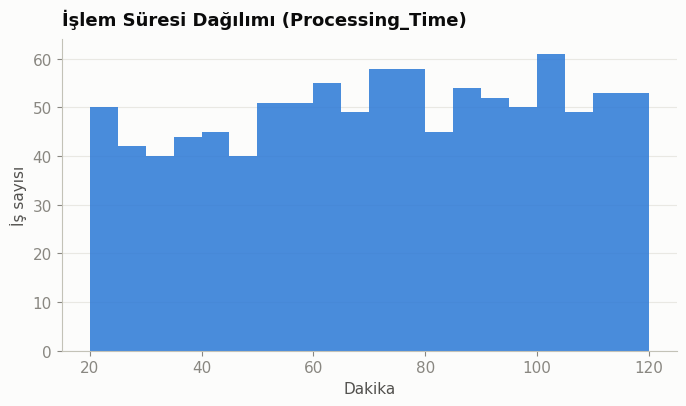

In [ ]:
pt = df['Processing_Time'].values

ks = stats.kstest(pt, 'uniform', args=(20, 100))  # scipy uniform(loc, scale) -> [20, 20+100]
print(f"KS testi (sürekli yaklaşıklama, Uniform(20,120)): statistic={ks.statistic:.4f}, p={ks.pvalue:.4f}")


full_range = np.arange(20, 121)
counts_series = pd.Series(0, index=full_range)
vals, counts = np.unique(pt, return_counts=True)
counts_series.update(pd.Series(counts, index=vals))
expected = np.full(len(full_range), len(pt) / len(full_range))
chi2_pt, p_pt = stats.chisquare(counts_series.values, expected)
print(f"Ki-kare uygunluk testi (ayrık Uniform 20-120): chi2={chi2_pt:.3f}, p={p_pt:.4f}")
print("-> Her iki test de p > 0.05: Uniform(20,120) dk hipotezi reddedilemiyor (veri bu dağılımla tutarlı).")

fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(pt, bins=20, color=CATEGORICAL[0], alpha=0.85)
style_ax(ax, "İşlem Süresi Dağılımı (Processing_Time)", "Dakika", "İş sayısı")
fig.tight_layout()
plt.show()

İşlem süresini operasyon tipinden bağımsız, tek bir dağılımdan ürettiğimizi düşündük.
Bunu sadece grup ortalamalarına bakarak değil, **Kruskal-Wallis** testiyle (dağılım şekli
hakkında varsayım yapmayan, ana test) ve karşılaştırma için **tek yönlü ANOVA** ile
doğruluyoruz.

In [ ]:
groups = [g['Processing_Time'].values for _, g in df.groupby('Operation_Type')]
kw_stat, kw_p = stats.kruskal(*groups)
anova_stat, anova_p = stats.f_oneway(*groups)
print(f"Kruskal-Wallis (Processing_Time ~ Operation_Type): H={kw_stat:.3f}, p={kw_p:.4f}")
print(f"Tek yönlü ANOVA (aynı karşılaştırma)             : F={anova_stat:.3f}, p={anova_p:.4f}")
print("-> Her iki test de p > 0.05: operasyon tipleri arasında istatistiksel olarak anlamlı")
print("   bir işlem-süresi farkı tespit edilmedi (bu, farkın olmadığının kanıtı değil —")
print("   sadece verideki farkın anlamlı bulunmadığı anlamına gelir).")

Kruskal-Wallis (Processing_Time ~ Operation_Type): H=1.620, p=0.8052
Tek yönlü ANOVA (aynı karşılaştırma)             : F=0.375, p=0.8268
-> Her iki test de p > 0.05: operasyon tipleri arasında istatistiksel olarak anlamlı
   bir işlem-süresi farkı tespit edilmedi (bu, farkın olmadığının kanıtı değil —
   sadece verideki farkın anlamlı bulunmadığı anlamına gelir).


### 1.3 İş Durumu Dağılımı (`Job_Status`) — Arıza ve Gecikme Oranları

Bir işin **zamanında tamamlanması (Completed)**, **gecikmeli başlaması (Delayed)** ya da
**arızalanıp başarısız olması (Failed)** durumları

Job_Status
Completed    673
Delayed      198
Failed       129
Name: count, dtype: int64

Yüzde:
 Job_Status
Completed    67.3
Delayed      19.8
Failed       12.9
Name: count, dtype: float64


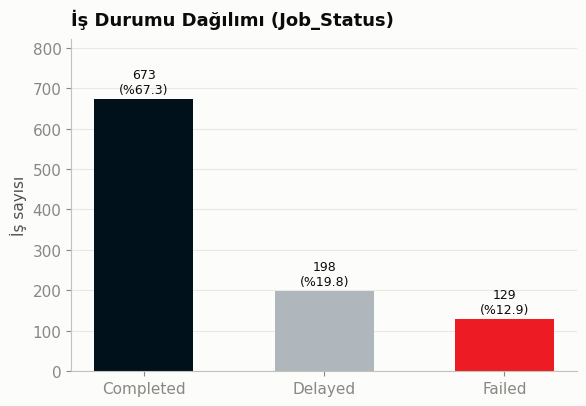

In [ ]:
order = ["Completed", "Delayed", "Failed"]
colors_map = {"Completed": "#01111B", "Delayed": "#AFB7BC", "Failed": "#ED1C24"}
counts = df['Job_Status'].value_counts()
probs = (counts / len(df) * 100).round(1)
print(counts)
print("\nYüzde:\n", probs)

fig, ax = plt.subplots(figsize=(6,4.2))
vals = [counts.get(o,0) for o in order]
bars = ax.bar(order, vals, color=[colors_map[o] for o in order], width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+8, f"{v}\n(%{100*v/len(df):.1f})", ha='center', va='bottom', fontsize=9)
style_ax(ax, "İş Durumu Dağılımı (Job_Status)", None, "İş sayısı")
ax.set_ylim(0, max(vals)*1.22)
fig.tight_layout()
plt.show()

Job_Status ~ Operation_Type ki-kare: chi2=3.676, p=0.8851
Job_Status ~ Machine_ID     ki-kare: chi2=12.091, p=0.1472
Job_Status ~ Zaman dönemi   ki-kare: chi2=9.755, p=0.1353


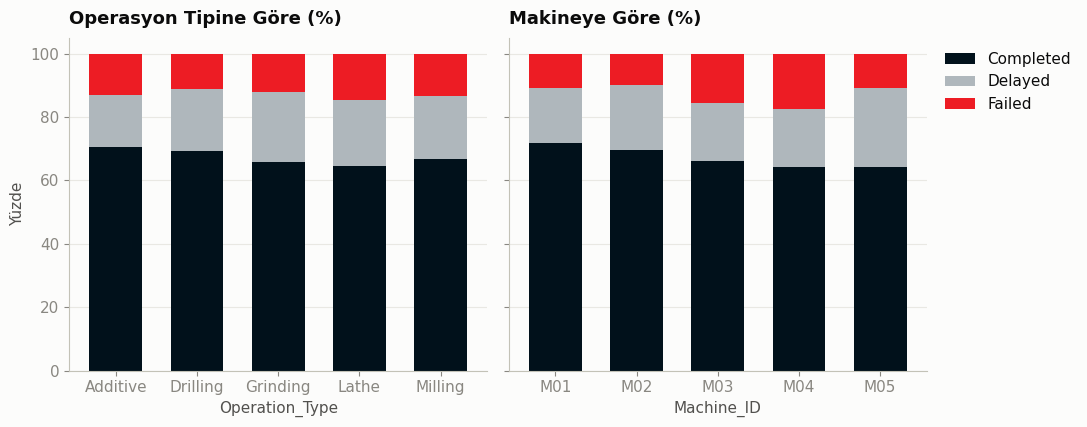

In [ ]:
ct_op = pd.crosstab(df['Operation_Type'], df['Job_Status'])
chi2_op, p_op, _, _ = stats.chi2_contingency(ct_op)
ct_m = pd.crosstab(df['Machine_ID'], df['Job_Status'])
chi2_m, p_m, _, _ = stats.chi2_contingency(ct_m)


df['time_bin'] = pd.qcut(df['Scheduled_Start'], 4, labels=['Dönem 1', 'Dönem 2', 'Dönem 3', 'Dönem 4'])
ct_t = pd.crosstab(df['time_bin'], df['Job_Status'])
chi2_t, p_t, _, _ = stats.chi2_contingency(ct_t)

print(f"Job_Status ~ Operation_Type ki-kare: chi2={chi2_op:.3f}, p={p_op:.4f}")
print(f"Job_Status ~ Machine_ID     ki-kare: chi2={chi2_m:.3f}, p={p_m:.4f}")
print(f"Job_Status ~ Zaman dönemi   ki-kare: chi2={chi2_t:.3f}, p={p_t:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(11,4.4), sharey=True)
props_op = pd.crosstab(df['Operation_Type'], df['Job_Status'], normalize='index')[order]*100
props_op.plot(kind='bar', stacked=True, ax=axes[0], color=[colors_map[o] for o in order], width=0.65, legend=False)
style_ax(axes[0], "Operasyon Tipine Göre (%)", None, "Yüzde")
axes[0].tick_params(axis='x', rotation=0)
props_m = pd.crosstab(df['Machine_ID'], df['Job_Status'], normalize='index')[order]*100
props_m.plot(kind='bar', stacked=True, ax=axes[1], color=[colors_map[o] for o in order], width=0.65)
style_ax(axes[1], "Makineye Göre (%)", None, None)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01,1.0))
fig.tight_layout()
plt.show()

### 1.4 Gerçekleşen Süre, Planlanan İşlem Süresi ile Aynı mı?

Bu, DES modelimizin en kritik varsayımlarından birini doğrudan etkiliyor: `Delayed` olarak
işaretlenen bir işte, makine **daha mı uzun** çalışıyor, yoksa iş **geç mi başlıyor**? Bunu
görmek için `Actual_End - Actual_Start` (gerçekleşen süre) ile `Processing_Time` (planlanan
işlem süresi) sütunlarını doğrudan karşılaştırıyoruz.

In [ ]:
df['actual_dur_min'] = (df['Actual_End'] - df['Actual_Start']).dt.total_seconds() / 60

comp_and_delayed = df[df['Job_Status'].isin(['Completed', 'Delayed'])]
diff = comp_and_delayed['actual_dur_min'] - comp_and_delayed['Processing_Time']
print("Actual_End - Actual_Start ile Processing_Time farkı (Completed + Delayed işler):")
print(diff.describe())
print(f"\nFark sıfırdan farklı olan iş sayısı: {(diff.abs() > 1e-6).sum()} / {len(diff)}")

Actual_End - Actual_Start ile Processing_Time farkı (Completed + Delayed işler):
count    871.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
dtype: float64

Fark sıfırdan farklı olan iş sayısı: 0 / 871


### 1.5 Gecikme Süresi Dağılımı



Delayed işlerde başlangıç gecikmesi (Actual_Start - Scheduled_Start):
count    198.000000
mean      20.146465
std        6.273283
min       10.000000
25%       14.000000
50%       21.000000
75%       26.000000
max       30.000000
dtype: float64

KS testi (gecikme vs Uniform(10,30)): statistic=0.0843, p-value=0.1128

Completed işlerde başlangıç sapması (referans için, ~0 olmalı):
count    673.000000
mean      -0.145617
std        3.138122
min       -5.000000
25%       -3.000000
50%        0.000000
75%        2.000000
max        5.000000
Name: start_delay_min, dtype: float64


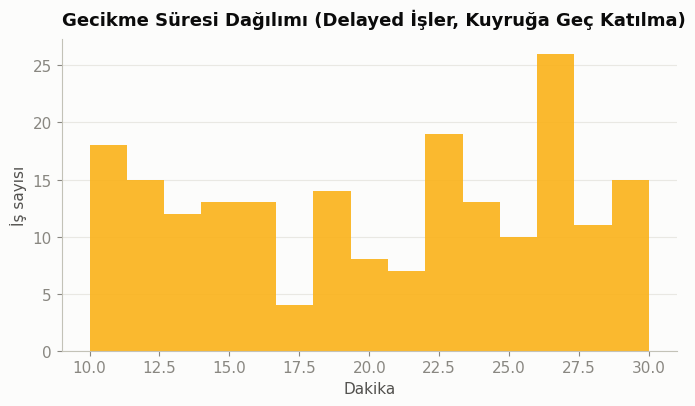

In [ ]:
df['start_delay_min'] = (df['Actual_Start'] - df['Scheduled_Start']).dt.total_seconds() / 60
delayed = df[df['Job_Status']=='Delayed']
delay_vals = delayed['start_delay_min'].values
print("Delayed işlerde başlangıç gecikmesi (Actual_Start - Scheduled_Start):")
print(pd.Series(delay_vals).describe())

ks_delay = stats.kstest(delay_vals, 'uniform', args=(10, 20))
print(f"\nKS testi (gecikme vs Uniform(10,30)): statistic={ks_delay.statistic:.4f}, p-value={ks_delay.pvalue:.4f}")

completed = df[df['Job_Status']=='Completed']
print("\nCompleted işlerde başlangıç sapması (referans için, ~0 olmalı):")
print(completed['start_delay_min'].describe())

fig, ax = plt.subplots(figsize=(7,4.2))
ax.hist(delay_vals, bins=15, color=STATUS['warning'], alpha=0.9)
style_ax(ax, "Gecikme Süresi Dağılımı (Delayed İşler, Kuyruğa Geç Katılma)", "Dakika", "İş sayısı")
fig.tight_layout()
plt.show()

### 1.6 Makine Kullanılabilirliği (`Machine_Availability`)

"Kullanılabilirlik oranı" (availability), o makinenin toplam zamanın yüzde kaçında gerçekten
kullanılabilir durumda olduğunu gösteren bir sayı. Bu alanın (a) kendi içinde nasıl dağıldığına
ve (b) iş sonucuyla (`Job_Status`) ilişkili olup olmadığına bakıyoruz.

Ki-kare uygunluk testi (ayrık Uniform(80,99) varsayımına karşı): chi2=33.800, p=0.0194
                 mean       std
Machine_ID                     
M01         89.141509  5.489220
M02         89.147619  6.097464
M03         89.419355  5.531869
M04         88.844221  5.909319
M05         89.284974  5.763267

Kruskal-Wallis (Machine_Availability ~ Job_Status): H=0.348, p=0.8402


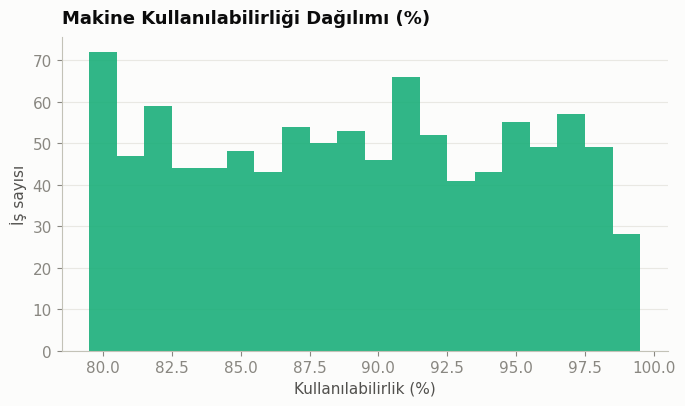

In [ ]:
ma = df['Machine_Availability'].values
vals_u, counts_u = np.unique(ma, return_counts=True)
chi2_ma, p_ma = stats.chisquare(counts_u, np.full(len(vals_u), len(ma)/len(vals_u)))
print(f"Ki-kare uygunluk testi (ayrık Uniform(80,99) varsayımına karşı): chi2={chi2_ma:.3f}, p={p_ma:.4f}")
print(df.groupby('Machine_ID')['Machine_Availability'].agg(['mean','std']))

kw_ma_stat, kw_ma_p = stats.kruskal(*[g['Machine_Availability'].values for _, g in df.groupby('Job_Status')])
print(f"\nKruskal-Wallis (Machine_Availability ~ Job_Status): H={kw_ma_stat:.3f}, p={kw_ma_p:.4f}")

fig, ax = plt.subplots(figsize=(7,4.2))
bins = np.arange(79.5, 100.5, 1)
ax.hist(ma, bins=bins, color=CATEGORICAL[2], alpha=0.9)
style_ax(ax, "Makine Kullanılabilirliği Dağılımı (%)", "Kullanılabilirlik (%)", "İş sayısı")
fig.tight_layout()
plt.show()

### 1.7 Varış Süreci (Interarrival Time)

İşlerin sisteme giriş sıklığını `Scheduled_Start` zaman damgalarından çıkarıyoruz.

In [ ]:
d_sorted = df.sort_values('Scheduled_Start')
interarrival = d_sorted['Scheduled_Start'].diff().dt.total_seconds().dropna() / 60
print(interarrival.describe())

count    999.0
mean      10.0
std        0.0
min       10.0
25%       10.0
50%       10.0
75%       10.0
max       10.0
Name: Scheduled_Start, dtype: float64


### 1.9 Makine Bazında Parametre Farklılıkları (Üç-İstasyonlu Hat İçin)



In [ ]:
groups_m = [g['Processing_Time'].values for _, g in df.groupby('Machine_ID')]
kw_m_stat, kw_m_p = stats.kruskal(*groups_m)
anova_m_stat, anova_m_p = stats.f_oneway(*groups_m)
print(f"Processing_Time ~ Machine_ID: Kruskal-Wallis H={kw_m_stat:.3f} p={kw_m_p:.4f}   ANOVA F={anova_m_stat:.3f} p={anova_m_p:.4f}")
print(df.groupby('Machine_ID')['Processing_Time'].agg(['mean', 'std', 'count']).round(2))
print()

ct_mach = pd.crosstab(df['Machine_ID'], df['Job_Status'])
chi2_mach, p_mach, dof_mach, _ = stats.chi2_contingency(ct_mach)
print(f"Job_Status ~ Machine_ID ki-kare: chi2={chi2_mach:.3f} p={p_mach:.4f} (dof={dof_mach})")
print(ct_mach)
print("\nMakine bazında Failed oranı:")
print((ct_mach['Failed'] / ct_mach.sum(axis=1)).round(4))
print("\n-> Her iki test de p > 0.05: 5 gerçek makine arasında ne işlem süresinde ne de iş")
print("   sonucunda (arıza dahil) istatistiksel olarak anlamlı bir fark tespit edildi.")

Processing_Time ~ Machine_ID: Kruskal-Wallis H=2.833 p=0.5861   ANOVA F=0.659 p=0.6206
             mean    std  count
Machine_ID                     
M01         70.46  27.78    212
M02         74.02  29.22    210
M03         69.91  27.36    186
M04         71.60  28.92    199
M05         70.72  29.15    193

Job_Status ~ Machine_ID ki-kare: chi2=12.091 p=0.1472 (dof=8)
Job_Status  Completed  Delayed  Failed
Machine_ID                            
M01               152       37      23
M02               146       43      21
M03               123       34      29
M04               128       36      35
M05               124       48      21

Makine bazında Failed oranı:
Machine_ID
M01    0.1085
M02    0.1000
M03    0.1559
M04    0.1759
M05    0.1088
dtype: float64

-> Her iki test de p > 0.05: 5 gerçek makine arasında ne işlem süresinde ne de iş
   sonucunda (arıza dahil) istatistiksel olarak anlamlı bir fark tespit edildi.


## 2. Üç Makineli SimPy DES Modeli

### 2.1 SimPy'ın Anahtar Kavramları

- **`Environment` (`env`)**: simülasyonun saati — her şey onun üzerinden zaman ilerletir.
- **`Process` (süreç)**: `yield` kullanan bir Python fonksiyonu — bir işin senaryosunu tanımlar
  (kuyruğa gir, makineyi bekle, işlen, çık). `yield`, Python'a "burada duruyorum, zaman
  ilerleyince ya da kaynak boşalınca devam et" demenin yolu.
- **`Resource` (kaynak)**: kapasitesi sınırlı bir şey — bizim durumumuzda bir makine.
- **`Store` (depo)**: sınırlı kapasiteli bir **ara tampon** — bir üretici `put()` ile içine
  koyar, bir tüketici `get()` ile alır; kapasite dolduğunda `put()` **bloke olur** (Bölüm 2.2'de
  bunu tam olarak bu amaçla kullanacağız).
- **`env.timeout(süre)`**: "şu kadar dakika bekle" — işlem süresini simüle eder.

Tek makineli, sabit sürelerle çalışan bir örnek:

In [ ]:
import simpy

def job_demo(env, name, machine):
    print(f"{env.now:6.1f} dk: {name} kuyruğa girdi")
    with machine.request() as req:
        yield req
        print(f"{env.now:6.1f} dk: {name} makineye girdi, işleniyor...")
        yield env.timeout(4)
        print(f"{env.now:6.1f} dk: {name} işi bitti, makineden çıktı")

def job_generator_demo(env, machine):
    for i in range(4):
        env.process(job_demo(env, f"İş-{i+1}", machine))
        yield env.timeout(2)

env_demo = simpy.Environment()
machine_demo = simpy.Resource(env_demo, capacity=1)
env_demo.process(job_generator_demo(env_demo, machine_demo))
env_demo.run()

   0.0 dk: İş-1 kuyruğa girdi
   0.0 dk: İş-1 makineye girdi, işleniyor...
   2.0 dk: İş-2 kuyruğa girdi
   4.0 dk: İş-1 işi bitti, makineden çıktı
   4.0 dk: İş-3 kuyruğa girdi
   4.0 dk: İş-2 makineye girdi, işleniyor...
   6.0 dk: İş-4 kuyruğa girdi
   8.0 dk: İş-2 işi bitti, makineden çıktı
   8.0 dk: İş-3 makineye girdi, işleniyor...
  12.0 dk: İş-3 işi bitti, makineden çıktı
  12.0 dk: İş-4 makineye girdi, işleniyor...
  16.0 dk: İş-4 işi bitti, makineden çıktı


### 2.2 Hattın tasarımı


```
                         ┌── M1 ──┐
İş giriş kuyruğu ────────┤        ├── Sonlu ara tampon ── M3 ── Çıkış
                         └── M2 ──┘
```



In [ ]:
import random

DEFAULT_PARAMS = dict(

    PROC_MIN=20, PROC_MAX=120,
    P_DELAYED=0.198,                                  # 1.3 - HATTA (ise once) GEC SERBEST BIRAKMA olasiligi
    DELAY_MIN=10, DELAY_MAX=30,                       # Uniform(10,30) dk (1.5)
    REPAIR_MIN=45, REPAIR_MAX=90,                     # VARSAYIM: onarim suresi (veride yok, bkz 1.4)
    SPEED_MULT={0: 1.2, 1: 1.0, 2: 0.75},
    WEAR_DELTA={0: 1, 1: 2, 2: 4},                    # HER hiz secimi asinmayi ARTIRIR (farkli oranlarda)
    WEAR_CAP=15,
    BASE_FAIL=0.03, WEAR_SLOPE=0.013, MAX_FAIL=0.55,
    QUEUE_CAP=8,                                      # RL durumunu ayriklastirmak icin ust sinir


    M1_SPEED_FACTOR=0.90,       # M1 islem suresi = PROC_MIN/MAX * 0.90  (yuzde 10 DAHA HIZLI)
    M2_SPEED_FACTOR=1.10,
    M1_WEAR_SLOPE_FACTOR=1.15,  # M1: asinmaya karsi yuzde 15 DAHA HASSAS (biraz daha ariza-egilimli)
    M2_WEAR_SLOPE_FACTOR=0.85,  # M2: asinmaya karsi yuzde 15 DAHA DAYANIKLI (biraz daha guvenilir)

    BUFFER_CAP=5,               # VARSAYIM: M1/M2 ile M3 arasindaki SONLU ara tamponun kapasitesi (veride yok)

    W_TIME=1.0, W_QUEUE=3.0, W_FAIL=150.0, W_REPAIR=1.0, W_ENERGY=15.0,   # odul agirliklari (VARSAYIM, RL bolumunde yeniden ele alinacak)
)


def sample_outcome_pre(rng, p):

    return "Delayed" if rng.random() < p["P_DELAYED"] else "Completed"


def get_proc_range(station_name, p):
    # M1/M2: kucuk, simetrik, ACIKCA varsayimsal sapma (bkz 1.9). M3: SAPMASIZ referans.
    if station_name == "M1":
        return p["PROC_MIN"] * p["M1_SPEED_FACTOR"], p["PROC_MAX"] * p["M1_SPEED_FACTOR"]
    if station_name == "M2":
        return p["PROC_MIN"] * p["M2_SPEED_FACTOR"], p["PROC_MAX"] * p["M2_SPEED_FACTOR"]
    return p["PROC_MIN"], p["PROC_MAX"]


def get_wear_slope(station_name, p):
    if station_name == "M1":
        return p["WEAR_SLOPE"] * p["M1_WEAR_SLOPE_FACTOR"]
    if station_name == "M2":
        return p["WEAR_SLOPE"] * p["M2_WEAR_SLOPE_FACTOR"]
    return p["WEAR_SLOPE"]


def reward_components(action, t, own_q_after, failed_now, repair_time, p):

    r_time = -p["W_TIME"] * t
    r_queue = -p["W_QUEUE"] * own_q_after
    r_fail = -(p["W_FAIL"] + p["W_REPAIR"] * repair_time) if failed_now else 0.0
    r_energy = -p["W_ENERGY"] if action == 2 else 0.0
    total = r_time + r_queue + r_fail + r_energy
    return total, {"time": r_time, "queue": r_queue, "fail": r_fail, "energy": r_energy}


def parallel_station_process(env, station_name, station_id, resource, buffer,
                              row, busy_time, wear_state, rng, policy_fn, p, visit_counts=None):

    queue_join_time = env.now
    with resource.request() as req:
        yield req                                       # gercek SimPy kuyrugunda bekle
        wait = env.now - queue_join_time
        own_q = len(resource.queue)                      # bu istasyonun KENDI kuyrugu
        buf_len = len(buffer.items)                       # ortak tamponun O ANKI doluluğu
        wear = wear_state[station_name]
        proc_min, proc_max = get_proc_range(station_name, p)

        # Durum: (asinma, kendi_kuyruk, tampon_doluluk, istasyon_id) -- M3 ile AYNI 4-lu
        # yapida, ileride (RL) tek bir policy_fn'in her uc istasyonda da calisabilmesi icin.
        state = (wear, min(own_q, p["QUEUE_CAP"]), min(buf_len, p["BUFFER_CAP"]), station_id)
        action = policy_fn(state) if policy_fn is not None else 1   # policy yoksa: hep normal
        if visit_counts is not None:
            visit_counts[state + (action,)] += 1

        speed_mult = p["SPEED_MULT"][action]
        t = rng.uniform(proc_min, proc_max) * speed_mult

        wear_slope = get_wear_slope(station_name, p)
        p_fail_eff = min(p["BASE_FAIL"] + wear_slope * wear, p["MAX_FAIL"])   # asinmaya duyarli risk
        failed_now = rng.random() < p_fail_eff

        yield env.timeout(t)                             # islem suresi kadar makineyi mesgul et

        repair_time = 0.0
        if failed_now:
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)                # onarim yine makineyi BLOKE EDER
            new_wear = 0                                  # onarim = bakim, asinma sifirlanir
            # HURDA: onarim makineyi (fiziksel olarak) duzeltir, ama BU URUNU kurtarmaz --
            # urun burada kalici olarak hurdaya cikar, tampona/M3'e ASLA ilerlemez (asagida).
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][action])
        wear_state[station_name] = new_wear
        own_q_after = len(resource.queue)


        block_time = 0.0
        if not failed_now:
            block_start = env.now
            yield buffer.put(row)
            block_time = env.now - block_start
            row["buffer_enter_time"] = env.now

    # Bloke olma suresi de makinenin "mesgul/kullanilamaz" suresine dahildir -- bloke bir
    # makine yeni is ALAMAZ, yani kullanim oranina (utilization) bu sure de yansimalidir.
    busy_time[station_name] += (t + repair_time + block_time)
    r_total, r_parts = reward_components(action, t, own_q_after, failed_now, repair_time, p)
    row[f"{station_name}_wait"] = wait
    row[f"{station_name}_proc_time"] = t
    row[f"{station_name}_action"] = action
    row[f"{station_name}_failed"] = failed_now
    row[f"{station_name}_repair_time"] = repair_time
    row[f"{station_name}_block_time"] = block_time
    row[f"{station_name}_reward"] = r_total
    row[f"{station_name}_state"] = state
    row[f"{station_name}_queue_len"] = own_q
    row[f"{station_name}_decision_time"] = queue_join_time + wait
    for k, v in r_parts.items():
        row[f"{station_name}_r_{k}"] = v

    if failed_now:
        # HURDA: urun burada kaliciolarak biter -- job_proc bu donus degerine bakip
        # log'a KENDISI ekleyecek (M3 dongusune hic ulasmadigi icin m3_loop_process bunu
        # goremez).
        row["status"] = f"failed_{station_name}"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
    return failed_now


def m3_loop_process(env, buffer, busy_time, wear_state, rng, policy_fn, p, log, visit_counts=None):

    while True:
        row = yield buffer.get()                          # tampon bosken burada BEKLER
        row["buffer_wait_time"] = env.now - row["buffer_enter_time"]
        own_q = len(buffer.items)                          # M3'u bekleyen DIGER urun sayisi
        wear = wear_state["M3"]

        state = (wear, min(own_q, p["QUEUE_CAP"]), 0, 2)
        action = policy_fn(state) if policy_fn is not None else 1
        if visit_counts is not None:
            visit_counts[state + (action,)] += 1

        t = rng.uniform(p["PROC_MIN"], p["PROC_MAX"]) * p["SPEED_MULT"][action]
        p_fail_eff = min(p["BASE_FAIL"] + p["WEAR_SLOPE"] * wear, p["MAX_FAIL"])
        failed_now = rng.random() < p_fail_eff

        yield env.timeout(t)

        repair_time = 0.0
        if failed_now:
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)
            new_wear = 0
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][action])
        wear_state["M3"] = new_wear
        busy_time["M3"] += (t + repair_time)   # M3 hic bloke olmaz -- cikisin kendisi sinirsiz

        r_total, r_parts = reward_components(action, t, own_q, failed_now, repair_time, p)
        row["M3_action"] = action
        row["M3_proc_time"] = t
        row["M3_failed"] = failed_now
        row["M3_repair_time"] = repair_time
        row["M3_reward"] = r_total
        row["M3_state"] = state
        row["M3_queue_len"] = own_q
        for k, v in r_parts.items():
            row[f"M3_r_{k}"] = v


        row["status"] = "failed_M3" if failed_now else "completed"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
        log.append(row)


def job_proc(env, name, m1, m2, buffer, log, busy_time, wear_state, rng, routing_fn, policy_fn, p, visit_counts=None):
    row = {"name": name, "arrive": env.now}


    outcome_pre = sample_outcome_pre(rng, p)
    release_delay = 0.0
    if outcome_pre == "Delayed":
        release_delay = rng.uniform(p["DELAY_MIN"], p["DELAY_MAX"])
        yield env.timeout(release_delay)
    row["release_delay"] = release_delay


    if routing_fn is not None:
        routing_state = (len(m1.queue), len(m2.queue))
        chosen = routing_fn(routing_state)
    else:
        chosen = rng.choice([0, 1])
    row["routed_to"] = "M1" if chosen == 0 else "M2"

    if chosen == 0:
        failed = yield from parallel_station_process(env, "M1", 0, m1, buffer, row, busy_time, wear_state,
                                                       rng, policy_fn, p, visit_counts)
    else:
        failed = yield from parallel_station_process(env, "M2", 1, m2, buffer, row, busy_time, wear_state,
                                                       rng, policy_fn, p, visit_counts)
    if failed:
        # HURDA: is M1/M2'de bitti, tampona/M3'e HIC ulasmadi -- log'a BURADA, job_proc'un
        # kendisi ekliyor (aksi halde bu is hic loglanmazdi).
        log.append(row)



def job_generator(env, m1, m2, buffer, log, busy_time, wear_state, rng, n_jobs, interarrival,
                   routing_fn, policy_fn, p, visit_counts=None):

    for i in range(n_jobs):
        env.process(job_proc(env, f"İş-{i+1}", m1, m2, buffer, log, busy_time, wear_state, rng,
                              routing_fn, policy_fn, p, visit_counts))
        if i < n_jobs - 1:
            yield env.timeout(interarrival)


def _simulate_line_raw(n_jobs, interarrival, seed, routing_fn, policy_fn, p, visit_counts=None):
    # Dusuk seviyeli calistirici -- run_line_simulation (Bolum 2/3) ve ileride RL egitim
    # dongusu bu FONKSIYONU paylasacak (ayri bir simulasyon kopyasi degil, ayni motor).
    rng = random.Random(seed)
    env = simpy.Environment()
    m1 = simpy.Resource(env, capacity=1)
    m2 = simpy.Resource(env, capacity=1)
    buffer = simpy.Store(env, capacity=p["BUFFER_CAP"])   # SONLU ara tampon
    wear_state = {"M1": 0, "M2": 0, "M3": 0}
    log, busy_time = [], {"M1": 0.0, "M2": 0.0, "M3": 0.0}
    env.process(job_generator(env, m1, m2, buffer, log, busy_time, wear_state, rng, n_jobs,
                               interarrival, routing_fn, policy_fn, p, visit_counts))
    env.process(m3_loop_process(env, buffer, busy_time, wear_state, rng, policy_fn, p, log, visit_counts))
    env.run()
    return log, busy_time, env.now


def run_line_simulation(n_jobs=60, interarrival=100, seed=42, routing_fn=None, policy_fn=None,
                         params=None, visit_counts=None):

    p = params if params is not None else DEFAULT_PARAMS
    log, busy_time, sim_end = _simulate_line_raw(n_jobs, interarrival, seed, routing_fn, policy_fn, p, visit_counts)
    df = pd.DataFrame(log).sort_values("arrive").reset_index(drop=True)


    generated_jobs = len(df)
    n_failed_m1 = int(df["M1_failed"].sum())
    n_failed_m2 = int(df["M2_failed"].sum())
    n_failed_m3 = int(df["M3_failed"].sum())
    failed_total = n_failed_m1 + n_failed_m2 + n_failed_m3
    completed_mask = df["status"] == "completed"
    completed_jobs = int(completed_mask.sum())
    total_repair = float(df["M1_repair_time"].sum() + df["M2_repair_time"].sum() + df["M3_repair_time"].sum())
    total_reward = float(df["M1_reward"].sum() + df["M2_reward"].sum() + df["M3_reward"].sum())
    m1_jobs, m2_jobs = df[df.routed_to == "M1"], df[df.routed_to == "M2"]
    action_counts = pd.concat([df["M1_action"], df["M2_action"], df["M3_action"]]).dropna().value_counts()
    n_dec = action_counts.sum()


    m1_block_ok = m1_jobs.loc[m1_jobs["M1_failed"] == False, "M1_block_time"]  # noqa: E712 (object-dtype bool+NaN karisimi -- '~' guvenilir degil)
    m2_block_ok = m2_jobs.loc[m2_jobs["M2_failed"] == False, "M2_block_time"]  # noqa: E712

    metrics = {
        "generated_jobs": generated_jobs,
        "completed_jobs": completed_jobs,
        "failed_M1": n_failed_m1,
        "failed_M2": n_failed_m2,
        "failed_M3": n_failed_m3,
        "failed_total": failed_total,
        "scrap_rate_pct": float(failed_total / generated_jobs * 100),
        "avg_M1_wait": float(m1_jobs["M1_wait"].mean()) if len(m1_jobs) else float("nan"),
        "avg_M2_wait": float(m2_jobs["M2_wait"].mean()) if len(m2_jobs) else float("nan"),
        "avg_buffer_wait": float(df["buffer_wait_time"].mean()),
        "avg_flow_time_completed": float(df.loc[completed_mask, "flow_time"].mean()) if completed_jobs else float("nan"),
        "M1_utilization_pct": float(busy_time["M1"] / sim_end * 100),
        "M2_utilization_pct": float(busy_time["M2"] / sim_end * 100),
        "M3_utilization_pct": float(busy_time["M3"] / sim_end * 100),
        "good_throughput_per_hour": float(completed_jobs / (sim_end / 60)),
        "n_failures": failed_total,
        "total_repair_time": total_repair,
        "total_reward": total_reward,
        "pct_routed_M1": float((df.routed_to == "M1").mean() * 100),
        "avg_M1_block_time": float(m1_block_ok.mean()) if len(m1_block_ok) else 0.0,
        "avg_M2_block_time": float(m2_block_ok.mean()) if len(m2_block_ok) else 0.0,
        "action_pct_yavas": float(action_counts.get(0, 0) / n_dec * 100),
        "action_pct_normal": float(action_counts.get(1, 0) / n_dec * 100),
        "action_pct_hizli": float(action_counts.get(2, 0) / n_dec * 100),
        "sim_end": sim_end,
    }
    return df, metrics


PROC_MIN, PROC_MAX = DEFAULT_PARAMS["PROC_MIN"], DEFAULT_PARAMS["PROC_MAX"]
WEAR_CAP, QUEUE_CAP, BUFFER_CAP = DEFAULT_PARAMS["WEAR_CAP"], DEFAULT_PARAMS["QUEUE_CAP"], DEFAULT_PARAMS["BUFFER_CAP"]

### 2.3 İlk Deneme: Veriden Gelen 10 Dakikalık Varış Aralığıyla Çalıştıralım



In [ ]:
df_test, metrics_test = run_line_simulation(n_jobs=15, interarrival=10, seed=42)
df_test[["name","arrive","routed_to","status","M1_wait","M2_wait","buffer_wait_time","leave"]].round(1)

,name,arrive,routed_to,status,M1_wait,M2_wait,buffer_wait_time,leave
0,İş-1,0,M1,failed_M3,0.0,NaN,4.9,220.0
1,İş-2,10,M2,completed,NaN,0.0,0.0,89.6
2,İş-3,20,M1,completed,64.7,NaN,85.0,276.5
3,İş-4,30,M1,completed,105.0,NaN,34.8,357.4
4,İş-5,40,M2,failed_M2,NaN,7.5,NaN,232.2
5,İş-6,50,M2,completed,NaN,182.2,80.2,441.4
6,İş-7,60,M1,completed,181.7,NaN,97.4,464.6
7,İş-8,70,M2,completed,NaN,207.2,85.2,511.4
8,İş-9,80,M2,completed,NaN,281.8,94.2,636.9
9,İş-10,90,M1,completed,254.0,NaN,115.2,571.0


### 2.4 Trafik Yoğunluğu (ρ) — Üç İstasyonlu Hat İçin

Artık **üç ayrı** ρ değerimiz var — biri her paralel makine için, biri M3 için:

$$\rho_{M1} = \frac{E[\text{hizmet}_{M1}]}{2 \times \text{varışlar arası süre}} \qquad
\rho_{M2} = \frac{E[\text{hizmet}_{M2}]}{2 \times \text{varışlar arası süre}} \qquad
\rho_{M3} = \frac{E[\text{hizmet}_{M3}]}{\text{varışlar arası süre}}$$




In [ ]:
CALIB_SEEDS = list(range(7, 17))
p_fail_m1, p_fail_m2, p_fail_m3, proc_ests, repair_ests = [], [], [], [], []
for cs in CALIB_SEEDS:
    df_calib, m_calib = run_line_simulation(n_jobs=800, interarrival=100, seed=cs)
    n_m1, n_m2 = (df_calib.routed_to == "M1").sum(), (df_calib.routed_to == "M2").sum()
    p_fail_m1.append(df_calib.loc[df_calib.routed_to == "M1", "M1_failed"].sum() / n_m1)
    p_fail_m2.append(df_calib.loc[df_calib.routed_to == "M2", "M2_failed"].sum() / n_m2)
    p_fail_m3.append(df_calib["M3_failed"].sum() / len(df_calib))
    proc_ests.append(df_calib["M3_proc_time"].mean())
    repair_vals = df_calib.loc[df_calib["M3_failed"] == True, "M3_repair_time"]  # noqa: E712 (object-dtype bool+NaN -- bare bool-mask NaN'de patlar)
    if len(repair_vals) > 0:
        repair_ests.append(repair_vals.mean())

p_fail_m1_est, p_fail_m2_est, p_fail_m3_est = float(np.mean(p_fail_m1)), float(np.mean(p_fail_m2)), float(np.mean(p_fail_m3))
mean_proc_est = float(np.mean(proc_ests))
mean_repair_est = float(np.mean(repair_ests))
data_fail_rate = counts["Failed"] / counts.sum()

print(f"Kalibrasyon ({len(CALIB_SEEDS)} tohum x 800 iş, normal hız, karar mekanizması yok):")
print(f"  M1 (hızlı/az-güvenilir) ort. arıza olasılığı : {p_fail_m1_est:.4f}")
print(f"  M2 (yavaş/güvenilir)    ort. arıza olasılığı : {p_fail_m2_est:.4f}")
print(f"  M3 (referans, sapmasız) ort. arıza olasılığı : {p_fail_m3_est:.4f}")
print(f"  Hat geneli ortalama (M1+M2 birleşik)         : {(p_fail_m1_est + p_fail_m2_est) / 2:.4f}")
print(f"  Verideki gerçek Failed oranı (Bölüm 1.3)     : {data_fail_rate:.4f}")
print(f"  Ortalama işlem süresi (M3, referans)         : {mean_proc_est:.1f} dk")
print(f"  Arıza olduğunda ortalama onarım süresi       : {mean_repair_est:.1f} dk")

def e_service(proc_min, proc_max, p_fail, repair_mean):
    return (proc_min + proc_max) / 2 + p_fail * repair_mean

p = DEFAULT_PARAMS
E_m1 = e_service(p["PROC_MIN"]*p["M1_SPEED_FACTOR"], p["PROC_MAX"]*p["M1_SPEED_FACTOR"], p_fail_m1_est, mean_repair_est)
E_m2 = e_service(p["PROC_MIN"]*p["M2_SPEED_FACTOR"], p["PROC_MAX"]*p["M2_SPEED_FACTOR"], p_fail_m2_est, mean_repair_est)
E_m3 = e_service(p["PROC_MIN"], p["PROC_MAX"], p_fail_m3_est, mean_repair_est)
# HURDA duzeltmesi: M3'e ULASAN urunlerin orani -- M1/M2'de arizalanan urun M3'e hic gelmiyor.
survival_fraction = 1 - (p_fail_m1_est + p_fail_m2_est) / 2
print(f"\nE[hizmet_M1]={E_m1:.1f} dk   E[hizmet_M2]={E_m2:.1f} dk   E[hizmet_M3]={E_m3:.1f} dk")
print(f"Hayatta kalma orani (M1/M2'yi basariyla gecip M3'e ulasan urun oran)={survival_fraction:.3f}\n")

for ia in [40, 60, 70, 80, 90, 100, 110, 120]:
    rho_m1, rho_m2 = E_m1 / (2*ia), E_m2 / (2*ia)
    rho_m3 = E_m3 * survival_fraction / ia
    durum = "KARARSIZ (M3 darboğaz olabilir)" if rho_m3 >= 1 else "kararlı (kaba tahmin)"
    print(f"Varış aralığı={ia:>3} dk -> rho_M1={rho_m1:.2f}  rho_M2={rho_m2:.2f}  rho_M3={rho_m3:.2f}  [{durum}]")

Kalibrasyon (10 tohum x 800 iş, normal hız, karar mekanizması yok):
  M1 (hızlı/az-güvenilir) ort. arıza olasılığı : 0.1404
  M2 (yavaş/güvenilir)    ort. arıza olasılığı : 0.1211
  M3 (referans, sapmasız) ort. arıza olasılığı : 0.1136
  Hat geneli ortalama (M1+M2 birleşik)         : 0.1307
  Verideki gerçek Failed oranı (Bölüm 1.3)     : 0.1290
  Ortalama işlem süresi (M3, referans)         : 69.8 dk
  Arıza olduğunda ortalama onarım süresi       : 66.9 dk

E[hizmet_M1]=72.4 dk   E[hizmet_M2]=85.1 dk   E[hizmet_M3]=77.6 dk
Hayatta kalma orani (M1/M2'yi basariyla gecip M3'e ulasan urun oran)=0.869

Varış aralığı= 40 dk -> rho_M1=0.90  rho_M2=1.06  rho_M3=1.69  [KARARSIZ (M3 darboğaz olabilir)]
Varış aralığı= 60 dk -> rho_M1=0.60  rho_M2=0.71  rho_M3=1.12  [KARARSIZ (M3 darboğaz olabilir)]
Varış aralığı= 70 dk -> rho_M1=0.52  rho_M2=0.61  rho_M3=0.96  [kararlı (kaba tahmin)]
Varış aralığı= 80 dk -> rho_M1=0.45  rho_M2=0.53  rho_M3=0.84  [kararlı (kaba tahmin)]
Varış aralığı= 90 dk -> rh

### 2.5 Düzeltilmiş Model

In [ ]:
random_check_rows = []
for n in [60, 200, 500]:
    for seed in range(10):
        _, m = run_line_simulation(n_jobs=n, interarrival=100, seed=seed)
        random_check_rows.append({"n_jobs": n, "seed": seed,
                                   "avg_flow_time_completed": m["avg_flow_time_completed"],
                                   "M3_utilization_pct": m["M3_utilization_pct"],
                                   "scrap_rate_pct": m["scrap_rate_pct"]})
check_df = pd.DataFrame(random_check_rows)
summary = check_df.groupby("n_jobs")[["avg_flow_time_completed", "M3_utilization_pct", "scrap_rate_pct"]].agg(["mean", "std"])
print("Ortalama akış süresi (tamamlananlar), M3 kullanım oranı ve hurda oranı, koşu uzunluğuna göre (10 farklı tohumun ortalaması):")
print(summary.round(2))

Ortalama akış süresi (tamamlananlar), M3 kullanım oranı ve hurda oranı, koşu uzunluğuna göre (10 farklı tohumun ortalaması):
       avg_flow_time_completed       M3_utilization_pct       scrap_rate_pct  \
                          mean   std               mean   std           mean   
n_jobs                                                                         
60                      177.87  8.93              69.24  4.21          23.33   
200                     174.24  6.02              68.53  2.77          24.35   
500                     174.25  2.10              68.57  1.12          24.32   

              
         std  
n_jobs        
60      2.83  
200     1.86  
500     1.02  


In [ ]:
df_sim, baseline_metrics = run_line_simulation(n_jobs=60, interarrival=100, seed=42)
sim_end = baseline_metrics["sim_end"]
df_sim.head(10)[["name","arrive","routed_to","status","M1_wait","M2_wait","buffer_wait_time","leave","flow_time"]].round(1)

,name,arrive,routed_to,status,M1_wait,M2_wait,buffer_wait_time,leave,flow_time
0,İş-1,0,M1,completed,0.0,NaN,0.0,118.7,118.7
1,İş-2,100,M1,failed_M1,0.0,NaN,NaN,220.4,120.4
2,İş-3,200,M1,completed,20.4,NaN,0.0,379.0,179.0
3,İş-4,300,M2,failed_M2,NaN,0.0,NaN,471.3,171.3
4,İş-5,400,M2,completed,NaN,71.3,0.0,564.8,164.8
5,İş-6,500,M1,completed,0.0,NaN,12.7,589.2,89.2
6,İş-7,600,M1,completed,0.0,NaN,0.0,778.0,178.0
7,İş-8,700,M1,failed_M3,0.0,NaN,55.9,909.5,209.5
8,İş-9,800,M1,completed,0.0,NaN,57.2,996.5,196.5
9,İş-10,900,M1,failed_M1,0.0,NaN,NaN,1067.7,167.7


### 2.6 Hızlandırma Problemi: Kuyruk Uzunluğuna Bağlı Adaptif Hizmet Hızı

*(Önceki sürümden korunan bir sağlık kontrolü — RL'den önce, basit bir kural.)* Bir istasyon
işlenmeye başlarken, o istasyonun **kendi** kuyruğunda `QUEUE_THRESHOLD` kadar veya daha fazla
iş bekliyorsa hızlansın, aksi halde normal hızda devam etsin. Durumun (`state`) dördü de
`(aşınma, kendi_kuyruk, tampon/ikincil_kuyruk, istasyon_id)` biçiminde **aynı** yapıda
olduğundan, bu kural M1, M2 ve M3'ün **üçünde de** değişmeden çalışıyor (RL bölümü de ileride
bu aynı durum yapısını kullanacak).



In [ ]:
QUEUE_THRESHOLD = 2   # kuyrukta bu kadar (veya fazla) is bekliyorsa hizlanma devreye girer

def heuristic_speedup_policy(state):
    wear, own_q, secondary_q, station_id = state
    return 2 if own_q >= QUEUE_THRESHOLD else 1

Bu mekanizmayı, kasıtlı olarak yüklü bir senaryoda (`interarrival=60`) deneyelim — 20
farklı tohumla karşılaştırıp ortalama, standart sapma ve eşleştirilmiş t-testi raporluyoruz.

In [ ]:
from scipy import stats as sps

EVAL_SEEDS_26 = list(range(20))

def multi_seed_run(policy_fn, n_jobs=60, interarrival=60, seeds=EVAL_SEEDS_26):
    rows = []
    for s in seeds:
        _, m = run_line_simulation(n_jobs=n_jobs, interarrival=interarrival, seed=s, policy_fn=policy_fn)
        rows.append(m)
    return pd.DataFrame(rows)

base_26 = multi_seed_run(None)
ada_26 = multi_seed_run(heuristic_speedup_policy)

def report_ci(df, name, col):
    m_, s_ = df[col].mean(), df[col].std()
    ci = sps.t.interval(0.95, len(df) - 1, loc=m_, scale=sps.sem(df[col])) if s_ > 0 else (m_, m_)
    print(f"{name:10s} {col:20s} ort={m_:9.2f}  std={s_:7.2f}  %95 GA=({ci[0]:.2f}, {ci[1]:.2f})")

print(f"--- interarrival=60, {len(EVAL_SEEDS_26)} tohum ortalaması ---\n")
for col in ["avg_flow_time_completed", "M3_utilization_pct", "good_throughput_per_hour", "scrap_rate_pct"]:
    report_ci(base_26, "baseline", col)
    report_ci(ada_26, "adaptive", col)
    print()

t1, p1 = sps.ttest_rel(ada_26["avg_flow_time_completed"], base_26["avg_flow_time_completed"])
t2, p2 = sps.ttest_rel(ada_26["good_throughput_per_hour"], base_26["good_throughput_per_hour"])
print(f"Eşleştirilmiş t-testi (adaptive - baseline), akış süresi (tamamlananlar) : fark={ada_26['avg_flow_time_completed'].mean()-base_26['avg_flow_time_completed'].mean():+.1f}, t={t1:.2f}, p={p1:.2e}")
print(f"Eşleştirilmiş t-testi (adaptive - baseline), sağlam throughput          : fark={ada_26['good_throughput_per_hour'].mean()-base_26['good_throughput_per_hour'].mean():+.2f}, t={t2:.2f}, p={p2:.2e}")

--- interarrival=60, 20 tohum ortalaması ---

baseline   avg_flow_time_completed ort=   474.17  std= 123.06  %95 GA=(416.58, 531.76)
adaptive   avg_flow_time_completed ort=   326.68  std=  63.12  %95 GA=(297.14, 356.22)

baseline   M3_utilization_pct   ort=    95.16  std=   2.68  %95 GA=(93.91, 96.42)
adaptive   M3_utilization_pct   ort=    94.42  std=   3.00  %95 GA=(93.02, 95.83)

baseline   good_throughput_per_hour ort=     0.65  std=   0.05  %95 GA=(0.63, 0.68)
adaptive   good_throughput_per_hour ort=     0.69  std=   0.05  %95 GA=(0.67, 0.72)

baseline   scrap_rate_pct       ort=    22.17  std=   3.51  %95 GA=(20.52, 23.81)
adaptive   scrap_rate_pct       ort=    24.00  std=   5.23  %95 GA=(21.55, 26.45)

Eşleştirilmiş t-testi (adaptive - baseline), akış süresi (tamamlananlar) : fark=-147.5, t=-5.17, p=5.50e-05
Eşleştirilmiş t-testi (adaptive - baseline), sağlam throughput          : fark=+0.04, t=3.38, p=3.17e-03


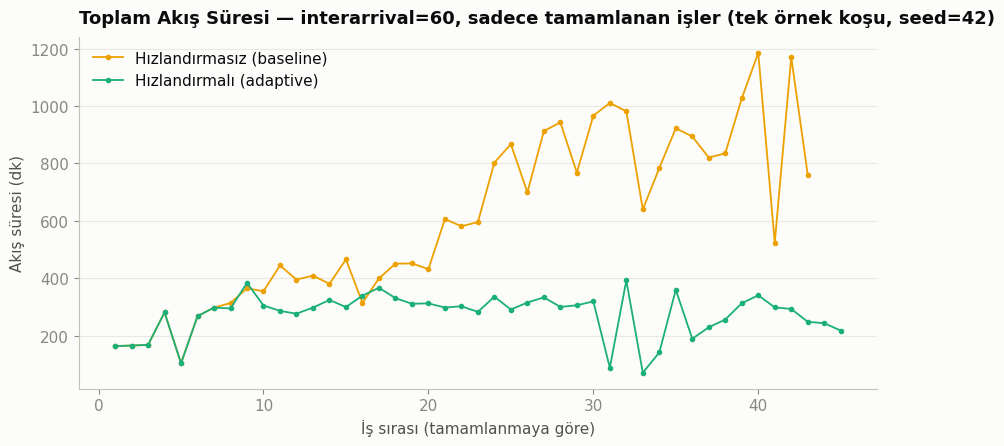

In [ ]:
df_base_60, _ = run_line_simulation(n_jobs=60, interarrival=60, seed=42)
df_ada_60, _ = run_line_simulation(n_jobs=60, interarrival=60, seed=42, policy_fn=heuristic_speedup_policy)

df_base_60_ok = df_base_60.loc[df_base_60.status == "completed"].reset_index(drop=True)
df_ada_60_ok = df_ada_60.loc[df_ada_60.status == "completed"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(range(1, len(df_base_60_ok)+1), df_base_60_ok["flow_time"], color=CATEGORICAL[3], marker="o",
        markersize=3, linewidth=1.3, label="Hızlandırmasız (baseline)")
ax.plot(range(1, len(df_ada_60_ok)+1), df_ada_60_ok["flow_time"], color=CATEGORICAL[2], marker="o",
        markersize=3, linewidth=1.3, label="Hızlandırmalı (adaptive)")
style_ax(ax, "Toplam Akış Süresi — interarrival=60, sadece tamamlanan işler (tek örnek koşu, seed=42)",
         "İş sırası (tamamlanmaya göre)", "Akış süresi (dk)")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Baseline Performans Metrikleri

In [ ]:
print("Özet metrikler (seed=42, karar mekanizması yok)")
print(f"Toplam simülasyon süresi     : {sim_end:.1f} dk")
print(f"Üretilen iş sayısı           : {baseline_metrics['generated_jobs']}")
print(f"Başarıyla tamamlanan iş sayısı: {baseline_metrics['completed_jobs']}")
print(f"  - M1'de hurdaya çıkan      : {baseline_metrics['failed_M1']}")
print(f"  - M2'de hurdaya çıkan      : {baseline_metrics['failed_M2']}")
print(f"  - M3'te hurdaya çıkan      : {baseline_metrics['failed_M3']}")
print(f"Hurda oranı (scrap rate)     : %{baseline_metrics['scrap_rate_pct']:.1f}")
print(f"M1'e yönlendirilen iş yüzdesi: %{baseline_metrics['pct_routed_M1']:.1f}")
print(f"Ortalama M1 bekleme          : {baseline_metrics['avg_M1_wait']:.1f} dk")
print(f"Ortalama M2 bekleme          : {baseline_metrics['avg_M2_wait']:.1f} dk")
print(f"Ortalama tampon bekleme      : {baseline_metrics['avg_buffer_wait']:.1f} dk")
print(f"Ort. akış süresi (tamamlanan): {baseline_metrics['avg_flow_time_completed']:.1f} dk")
print(f"M1 kullanım oranı            : {baseline_metrics['M1_utilization_pct']:.1f} %")
print(f"M2 kullanım oranı            : {baseline_metrics['M2_utilization_pct']:.1f} %")
print(f"M3 kullanım oranı            : {baseline_metrics['M3_utilization_pct']:.1f} %")
print(f"Sağlam throughput            : {baseline_metrics['good_throughput_per_hour']:.2f} iş/saat")
print(f"Toplam arıza sayısı          : {baseline_metrics['n_failures']}")
print(f"Toplam onarım/duruş süresi   : {baseline_metrics['total_repair_time']:.1f} dk")
print(f"Ort. M1 bloke olma süresi    : {baseline_metrics['avg_M1_block_time']:.1f} dk")
print(f"Ort. M2 bloke olma süresi    : {baseline_metrics['avg_M2_block_time']:.1f} dk")

with open("baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)
baseline_metrics

Özet metrikler (seed=42, karar mekanizması yok)
Toplam simülasyon süresi     : 6054.2 dk
Üretilen iş sayısı           : 60
Başarıyla tamamlanan iş sayısı: 43
  - M1'de hurdaya çıkan      : 7
  - M2'de hurdaya çıkan      : 3
  - M3'te hurdaya çıkan      : 7
Hurda oranı (scrap rate)     : %28.3
M1'e yönlendirilen iş yüzdesi: %65.0
Ortalama M1 bekleme          : 8.2 dk
Ortalama M2 bekleme          : 5.7 dk
Ortalama tampon bekleme      : 27.5 dk
Ort. akış süresi (tamamlanan): 180.5 dk
M1 kullanım oranı            : 46.7 %
M2 kullanım oranı            : 26.0 %
M3 kullanım oranı            : 70.6 %
Sağlam throughput            : 0.43 iş/saat
Toplam arıza sayısı          : 17
Toplam onarım/duruş süresi   : 1117.9 dk
Ort. M1 bloke olma süresi    : 0.0 dk
Ort. M2 bloke olma süresi    : 0.0 dk


{'generated_jobs': 60,
 'completed_jobs': 43,
 'failed_M1': 7,
 'failed_M2': 3,
 'failed_M3': 7,
 'failed_total': 17,
 'scrap_rate_pct': 28.333333333333332,
 'avg_M1_wait': 8.19680300277265,
 'avg_M2_wait': 5.681608338967997,
 'avg_buffer_wait': 27.505275059633195,
 'avg_flow_time_completed': 180.54899798634096,
 'M1_utilization_pct': 46.73240815032877,
 'M2_utilization_pct': 25.96163650179159,
 'M3_utilization_pct': 70.59576166355424,
 'good_throughput_per_hour': 0.4261516987632917,
 'n_failures': 17,
 'total_repair_time': 1117.8887581946656,
 'total_reward': -11267.025850355358,
 'pct_routed_M1': 65.0,
 'avg_M1_block_time': 0.0,
 'avg_M2_block_time': 0.0,
 'action_pct_yavas': 0.0,
 'action_pct_normal': 100.0,
 'action_pct_hizli': 0.0,
 'sim_end': 6054.182131591303}

### 3.1 Çoklu Tohumla Baseline

### 3.2 Parametrelerle İnteraktif Deneme

Aşağıdaki kaydırıcılar, Bölüm 2'de kurduğumuz `run_line_simulation` motorunu **farklı bir
`params` sözlüğüyle** çalıştırıyor — ayrı bir simülasyon yazmıyoruz, aynı motoru farklı
senaryolarla besliyoruz.

- `N_JOBS_OZEL`: Simülasyonda üretim hattına gönderilecek toplam iş/ürün sayısı.
- `INTERARRIVAL_OZEL`: İki ürünün üretim hattına gelişleri arasındaki süre.
- `PROC_MIN_OZEL` / `PROC_MAX_OZEL`: M3'ün (referans) alabileceği en kısa/en uzun işlem süresi.
- `P_DELAYED_OZEL`: Bir işin üretime/kuyruğa geç serbest bırakılma olasılığı.
- `BASE_FAIL_OZEL` / `WEAR_SLOPE_OZEL`: Aşınma=0 iken taban arıza olasılığı ve aşınma arttıkça
  bu olasılığın ne kadar hızlı yükseldiği (M3 referansı; M1/M2 kendi çarpanlarını uygular).
- `REPAIR_MIN_OZEL` / `REPAIR_MAX_OZEL`: Arıza oluştuğunda en kısa/en uzun tamir süresi.
- `BUFFER_CAP_OZEL`: M1/M2 ile M3 arasındaki sonlu ara tamponun kapasitesi.
- `SEED_OZEL`: Simülasyonda kullanılan rastgele sayı üretiminin başlangıç değeri.

(Kaba tahmin) ρ_M3≈1.88 -> UYARI: M3'te kuyruk büyüme eğiliminde olabilir!

Parametrelerle Sonuçlar
generated_jobs           : 100
completed_jobs           : 64
failed_M1                : 10
failed_M2                : 7
failed_M3                : 19
failed_total             : 36
scrap_rate_pct           : 36.00
avg_M1_wait              : 2641.91
avg_M2_wait              : 3468.69
avg_buffer_wait          : 770.59
avg_flow_time_completed  : 4314.89
M1_utilization_pct       : 86.14
M2_utilization_pct       : 96.66
M3_utilization_pct       : 98.77
good_throughput_per_hour : 0.26
n_failures               : 36
total_repair_time        : 3413.22
total_reward             : -41253.77
pct_routed_M1            : 48.00
avg_M1_block_time        : 133.62
avg_M2_block_time        : 100.79
action_pct_yavas         : 0.00
action_pct_normal        : 100.00
action_pct_hizli         : 0.00
sim_end                  : 14631.58


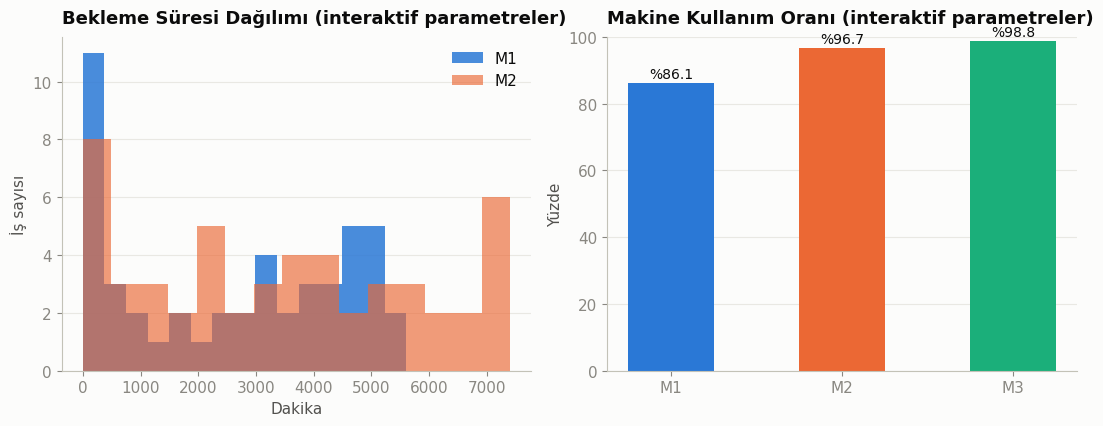

In [ ]:
# @markdown Simülasyon Parametreleri
N_JOBS_OZEL = 100  #@param {type:"slider", min:10, max:200, step:10}
INTERARRIVAL_OZEL = 70  #@param {type:"slider", min:10, max:300, step:5}
PROC_MIN_OZEL = 200  #@param {type:"integer"}
PROC_MAX_OZEL = 100  #@param {type:"integer"}
P_DELAYED_OZEL = 0.16  #@param {type:"slider", min:0, max:0.6, step:0.01}
BASE_FAIL_OZEL = 0.09  #@param {type:"slider", min:0, max:0.5, step:0.01}
WEAR_SLOPE_OZEL = 0.02  #@param {type:"slider", min:0, max:0.1, step:0.005}
REPAIR_MIN_OZEL = 90  #@param {type:"integer"}
REPAIR_MAX_OZEL = 100  #@param {type:"integer"}
BUFFER_CAP_OZEL = 5  #@param {type:"slider", min:1, max:20, step:1}
SEED_OZEL = 80  #@param {type:"integer"}

def build_params_ozel():
    p = dict(DEFAULT_PARAMS)
    p.update(dict(
        PROC_MIN=PROC_MIN_OZEL, PROC_MAX=PROC_MAX_OZEL,
        P_DELAYED=P_DELAYED_OZEL,
        BASE_FAIL=BASE_FAIL_OZEL, WEAR_SLOPE=WEAR_SLOPE_OZEL,
        REPAIR_MIN=REPAIR_MIN_OZEL, REPAIR_MAX=REPAIR_MAX_OZEL,
        BUFFER_CAP=BUFFER_CAP_OZEL,
    ))
    return p

params_ozel = build_params_ozel()

mean_proc_ozel = (PROC_MIN_OZEL + PROC_MAX_OZEL) / 2
mean_repair_ozel = (REPAIR_MIN_OZEL + REPAIR_MAX_OZEL) / 2
p_fail_rough_ozel = min(BASE_FAIL_OZEL + WEAR_SLOPE_OZEL * (WEAR_CAP / 2), params_ozel["MAX_FAIL"])
E_service_ozel = mean_proc_ozel + p_fail_rough_ozel * mean_repair_ozel
survival_fraction_ozel = 1 - p_fail_rough_ozel   # HURDA duzeltmesi (bkz 2.4)
rho_m3_ozel = E_service_ozel * survival_fraction_ozel / INTERARRIVAL_OZEL
print(f"(Kaba tahmin) ρ_M3≈{rho_m3_ozel:.2f} ", end="")
print("-> UYARI: M3'te kuyruk büyüme eğiliminde olabilir!" if rho_m3_ozel >= 1 else "-> kararlı bir sistem bekleniyor")

df_ozel, metrics_ozel = run_line_simulation(
    n_jobs=N_JOBS_OZEL, interarrival=INTERARRIVAL_OZEL, seed=SEED_OZEL, params=params_ozel,
)

print("\nParametrelerle Sonuçlar")
for k, v in metrics_ozel.items():
    print(f"{k:25s}: {v:.2f}" if isinstance(v, float) else f"{k:25s}: {v}")


fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].hist(df_ozel.loc[df_ozel.routed_to=="M1", "M1_wait"], bins=15, color=CATEGORICAL[0], alpha=0.85, label="M1")
axes[0].hist(df_ozel.loc[df_ozel.routed_to=="M2", "M2_wait"], bins=15, color=CATEGORICAL[1], alpha=0.65, label="M2")
style_ax(axes[0], "Bekleme Süresi Dağılımı (interaktif parametreler)", "Dakika", "İş sayısı")
axes[0].legend()

util_ozel = [metrics_ozel["M1_utilization_pct"], metrics_ozel["M2_utilization_pct"], metrics_ozel["M3_utilization_pct"]]
bars = axes[1].bar(["M1", "M2", "M3"], util_ozel, color=[CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]], width=0.5)
for b, v in zip(bars, util_ozel):
    axes[1].text(b.get_x()+b.get_width()/2, v+1.5, f"%{v:.1f}", ha="center", fontsize=10)
style_ax(axes[1], "Makine Kullanım Oranı (interaktif parametreler)", None, "Yüzde")
axes[1].set_ylim(0, 100)
fig.tight_layout()
plt.show()

### 3.1b Aynı Grafik, Çoklu Tohum (N=20, Havuzlanmış)

3'ün başındaki tek-tohumlu (seed=42) grafiğin **aynısı**, ama artık tek bir 60-işlik koşu
yerine 20 tohumun tamamından gelen işler bir arada — M1/M2 dengesizliği gibi tek-tohum
rastgelelik etkileri burada büyük ölçüde ortalamaya karışıyor.

Baseline, 20 farklı tohum üzerinden (N_JOBS=60, interarrival=100):

  avg_M1_wait            ort=     3.64  std=   2.88  %95 GA=(2.29, 4.98)
  avg_M2_wait            ort=     8.32  std=   4.95  %95 GA=(6.01, 10.64)
  avg_buffer_wait        ort=    22.79  std=   6.54  %95 GA=(19.74, 25.85)
  avg_flow_time_completed ort=   176.31  std=  12.09  %95 GA=(170.65, 181.97)
  M1_utilization_pct     ort=    34.79  std=   4.29  %95 GA=(32.78, 36.80)
  M2_utilization_pct     ort=    43.56  std=   7.78  %95 GA=(39.92, 47.20)
  M3_utilization_pct     ort=    68.63  std=   3.93  %95 GA=(66.79, 70.47)
  good_throughput_per_hour ort=     0.45  std=   0.02  %95 GA=(0.44, 0.46)
  scrap_rate_pct         ort=    23.83  std=   3.25  %95 GA=(22.31, 25.35)
  n_failures             ort=    14.30  std=   1.95  %95 GA=(13.39, 15.21)
  pct_routed_M1          ort=    48.25  std=   7.04  %95 GA=(44.96, 51.54)


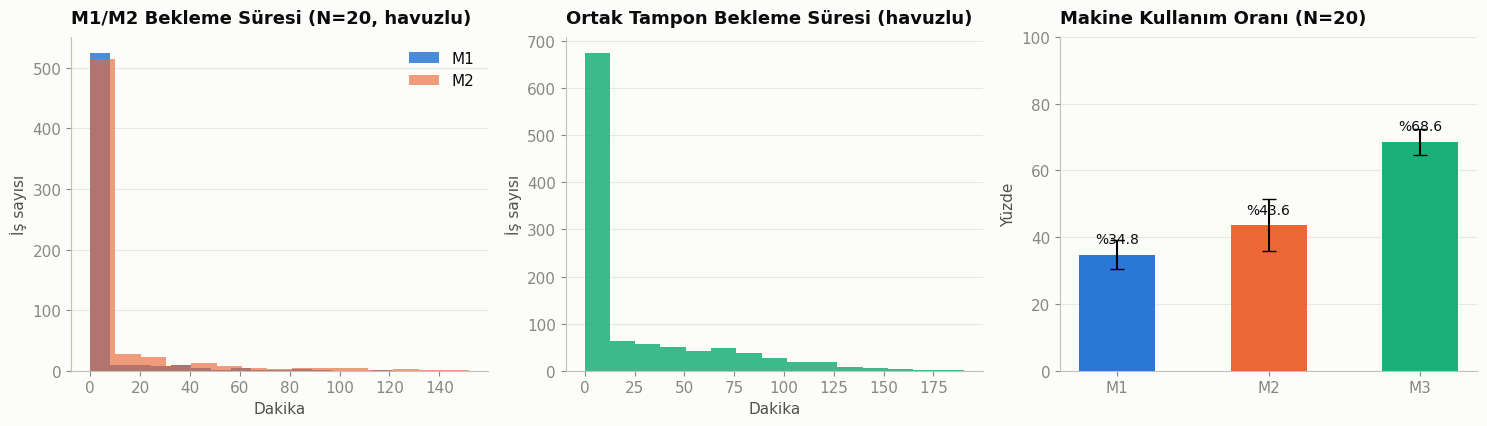

Havuzlanmış toplam iş: 1200  (M1'e giden: 579, M2'ye giden: 621)


In [ ]:
BASELINE_SEEDS = list(range(20))
baseline_rows = []
baseline_dfs = []   # her tohumun is-bazli df'i -- 3.1b'deki havuzlanmis grafik icin
for s in BASELINE_SEEDS:
    df_s, m = run_line_simulation(n_jobs=60, interarrival=100, seed=s)
    df_s = df_s.copy()
    df_s["seed"] = s
    baseline_dfs.append(df_s)
    baseline_rows.append(m)
baseline_df = pd.DataFrame(baseline_rows)
baseline_all_jobs = pd.concat(baseline_dfs, ignore_index=True)   # N=20 tohum x 60 is, havuzlanmis

print(f"Baseline, {len(BASELINE_SEEDS)} farklı tohum üzerinden (N_JOBS=60, interarrival=100):\n")
for col in ["avg_M1_wait", "avg_M2_wait", "avg_buffer_wait", "avg_flow_time_completed", "M1_utilization_pct",
            "M2_utilization_pct", "M3_utilization_pct", "good_throughput_per_hour", "scrap_rate_pct",
            "n_failures", "pct_routed_M1"]:
    m_, s_ = baseline_df[col].mean(), baseline_df[col].std()
    ci = sps.t.interval(0.95, len(baseline_df)-1, loc=m_, scale=sps.sem(baseline_df[col])) if s_ > 0 else (m_, m_)
    print(f"  {col:22s} ort={m_:9.2f}  std={s_:7.2f}  %95 GA=({ci[0]:.2f}, {ci[1]:.2f})")




fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].hist(baseline_all_jobs.loc[baseline_all_jobs.routed_to=="M1", "M1_wait"], bins=15, color=CATEGORICAL[0], alpha=0.85, label="M1")
axes[0].hist(baseline_all_jobs.loc[baseline_all_jobs.routed_to=="M2", "M2_wait"], bins=15, color=CATEGORICAL[1], alpha=0.65, label="M2")
style_ax(axes[0], f"M1/M2 Bekleme Süresi (N={len(BASELINE_SEEDS)}, havuzlu)", "Dakika", "İş sayısı")
axes[0].legend()

axes[1].hist(baseline_all_jobs["buffer_wait_time"].dropna(), bins=15, color=CATEGORICAL[2], alpha=0.85)
style_ax(axes[1], "Ortak Tampon Bekleme Süresi (havuzlu)", "Dakika", "İş sayısı")

util_mean = [baseline_df["M1_utilization_pct"].mean(), baseline_df["M2_utilization_pct"].mean(), baseline_df["M3_utilization_pct"].mean()]
util_std = [baseline_df["M1_utilization_pct"].std(), baseline_df["M2_utilization_pct"].std(), baseline_df["M3_utilization_pct"].std()]
bars = axes[2].bar(["M1", "M2", "M3"], util_mean, yerr=util_std, capsize=5, color=[CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]], width=0.5)
for b, v in zip(bars, util_mean):
    axes[2].text(b.get_x()+b.get_width()/2, v+3.5, f"%{v:.1f}", ha="center", fontsize=10)
style_ax(axes[2], "Makine Kullanım Oranı (N=20)", None, "Yüzde")
axes[2].set_ylim(0, 100)
fig.tight_layout()
plt.show()

n_m1 = int((baseline_all_jobs.routed_to == "M1").sum())
n_m2 = int((baseline_all_jobs.routed_to == "M2").sum())
print(f"Havuzlanmış toplam iş: {len(baseline_all_jobs)}  (M1'e giden: {n_m1}, M2'ye giden: {n_m2})")

## 4. Yıllık Ufuk, Dinamik Talep ve Makine Zaman Muhasebesi

*(RL'den ÖNCE eklenen bir DES genişletmesi — bu bölümde henüz RL/Q-learning YOK.)* Bölüm 2-3,
sabit sayıda iş (`n_jobs=60`), sabit bir varış aralığıyla (`interarrival=100`) çalışan **kısa**
koşulardı — bunlar hattın temel fiziğini (ρ, warm-up, hızlandırma etkisi) doğrulamak için
yeterliydi, ama gerçekçi bir **yıllık üretim** tablosu vermiyorlar. Bu bölümde üç değişiklik
yapıyoruz:

1. **Dinamik talep:** Varış aralığı artık sabit değil, günün saatine göre değişiyor (düşük/yoğun/
   normal talep rejimleri).
2. **Sabit iş sayısı yerine tam bir yıl:** Simülasyon artık `n_jobs` ile değil, `env.run(until=...)`
   ile **tam 365 gün** sonra duruyor — yıl sonunda hattın içinde (kuyrukta/tamponda/makinede)
   kalan ürünler **tamamlatılmıyor**, `WIP` (devam eden iş) olarak sayılıyor.
3. **Makine zamanının ayrıştırılması:** Önceki `M*_utilization_pct` tek bir "kullanım oranı"
   sayısıydı; burada her makine için işlem/onarım/bloke-olma/boşta süreleri **ayrı ayrı**,
   olay-tabanlı (event-driven) bir durum izleyiciyle takip ediliyor.

Bölüm 2-3'ün motoru (parametreler, arıza/hurda mantığı, sonlu tampon) **aynen korunuyor** —
burada sadece talep üretim mekanizması, koşu süresi ve zaman muhasebesi değişiyor. `DEFAULT_PARAMS`,
`get_proc_range`, `get_wear_slope`, `sample_outcome_pre` fonksiyonları Bölüm 2'den **olduğu gibi**
yeniden kullanılıyor.

### 4.1 Dinamik Talep: Gün İçi Rejimler (VARSAYIM)

Veri setinde gün içi saatlik talep dalgalanmasına dair **hiçbir bilgi yok** (Bölüm 1'de sadece
`Scheduled_Start` alanının sabit 10 dakikalık aralıklarla ilerlediğini gördük — 1.7). Bu yüzden
aşağıdaki üç rejim ve süreleri **tamamen sentetik bir modelleme varsayımıdır** — üretim
ortamlarında tipik olarak görülen "gece sakin, gündüz yoğun, akşamüstü orta" örüntüsünü temsil
etmesi için seçildi, veriden türetilmedi:

In [ ]:

INTERARRIVAL_BY_REGIME = {
    "LOW": 120,     # 00.00-08.00 -- dusuk talep: her 120 dk'da bir yeni is
    "PEAK": 60,     # 08.00-16.00 -- yogun talep: her 60 dk'da bir yeni is
    "NORMAL": 90,
}
_REGIME_BOUNDS = [(0, 8*60, "LOW"), (8*60, 16*60, "PEAK"), (16*60, 24*60, "NORMAL")]

def get_demand_regime(t):
    # Gunun hangi saatinde oldugumuzu env.now % 1440 (bir gunun dakika sayisi) ile buluyoruz.
    minute_of_day = t % 1440
    for start, end, regime in _REGIME_BOUNDS:
        if start <= minute_of_day < end:
            return regime
    return "NORMAL"

ANNUAL_HORIZON_MIN = 365 * 24 * 60  # tam 1 yil = 525600 dk
print(f"ANNUAL_HORIZON_MIN = {ANNUAL_HORIZON_MIN:,} dk (365 gun)")
print("Rejim kontrolu:", {h: get_demand_regime(h*60) for h in [0, 7, 8, 15, 16, 23]})

ANNUAL_HORIZON_MIN = 525,600 dk (365 gun)
Rejim kontrolu: {0: 'LOW', 7: 'LOW', 8: 'PEAK', 15: 'PEAK', 16: 'NORMAL', 23: 'NORMAL'}


In [ ]:
class MachineStateTracker:
    def __init__(self, env, name):
        self.env = env
        self.name = name
        self.current_state = "idle"   # t=0'da hicbir is yok -- makine BOSTA baslar
        self.state_start = env.now
        self.totals = {"processing": 0.0, "repair": 0.0, "blocked": 0.0, "idle": 0.0}

    def set_state(self, new_state):
        now = self.env.now
        self.totals[self.current_state] += (now - self.state_start)
        self.current_state = new_state
        self.state_start = now

    def finalize(self, horizon):
        # Simulasyon durdugunda ACIK olan durumu, yil sonuna kadar kapatiyoruz -- yarim kalan
        # islem/onarim boylece SADECE yil icinde kalan kismiyla sayiliyor.
        self.totals[self.current_state] += (horizon - self.state_start)
        self.current_state = None

### 4.2 Makine Zaman Muhasebesi: `MachineStateTracker`

Önceki bölümlerde kullanım oranı, `busy_time[station] += t` şeklinde **işlem bittiğinde**
toplanıyordu. Yıllık ufukta bu yaklaşım hatalı olur: `env.run(until=ANNUAL_HORIZON_MIN)` bir
sürecin **tam ortasında** (örn. bir onarımın yarısında) simülasyonu durdurabilir — bu durumda o
sürecin geri kalan kodu (ve `busy_time += t` satırı) **hiç çalışmaz**, yıl sonundaki yarım kalan
işlem/onarım süresi sessizce kaybolur.

Bunun yerine, her makine için bir `MachineStateTracker` tutuyoruz: makine bir duruma girdiğinde
(`processing`/`repair`/`blocked`/`idle`) `set_state(...)` çağrılıyor, önceki durumda geçen süre o
anda kapatılıp toplama ekleniyor. Simülasyon `ANNUAL_HORIZON_MIN`'de durduğunda, `finalize(...)`
o an **açık olan** durumu (yarım kalmış olsa bile) tam olarak yıl sonuna kadar kapatıyor — yani
"yıl sonunda devam eden işlem/onarımın yalnızca yıl içinde kalan kısmı" otomatik olarak doğru
hesaba katılıyor.

### 4.3  Dinamik Talep + Sonsuz Üretici + Hurda + Durum İzleme



In [ ]:
def parallel_station_process_annual(env, station_name, station_id, resource, buffer,
                                     row, tracker, wear_state, rng, policy_fn, p, visit_counts=None):
    queue_join_time = env.now
    with resource.request() as req:
        yield req
        wait = env.now - queue_join_time
        own_q = len(resource.queue)
        buf_len = len(buffer.items)
        wear = wear_state[station_name]
        proc_min, proc_max = get_proc_range(station_name, p)

        state = (wear, min(own_q, p["QUEUE_CAP"]), min(buf_len, p["BUFFER_CAP"]), station_id)
        action = policy_fn(state) if policy_fn is not None else 1
        if visit_counts is not None:
            visit_counts[state + (action,)] += 1

        tracker.set_state("processing")
        t = rng.uniform(proc_min, proc_max) * p["SPEED_MULT"][action]
        wear_slope = get_wear_slope(station_name, p)
        p_fail_eff = min(p["BASE_FAIL"] + wear_slope * wear, p["MAX_FAIL"])
        failed_now = rng.random() < p_fail_eff

        yield env.timeout(t)

        repair_time = 0.0
        if failed_now:
            tracker.set_state("repair")
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)          # onarim makineyi DUZELTIR
            new_wear = 0
            # HURDA (Bolum 2.2 ile ayni): onarim bu URUNU kurtarmaz, urun tampona/M3'e ilerlemez.
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][action])
        wear_state[station_name] = new_wear
        own_q_after = len(resource.queue)

        block_time = 0.0
        if not failed_now:
            tracker.set_state("blocked")
            block_start = env.now
            yield buffer.put(row)                   # tampon DOLUYSA burada BLOKE olunur
            block_time = env.now - block_start
            row["buffer_enter_time"] = env.now

        tracker.set_state("idle")

    row[f"{station_name}_wait"] = wait
    row[f"{station_name}_proc_time"] = t
    row[f"{station_name}_action"] = action
    row[f"{station_name}_failed"] = failed_now
    row[f"{station_name}_repair_time"] = repair_time
    row[f"{station_name}_block_time"] = block_time
    row[f"{station_name}_queue_len"] = own_q

    if failed_now:
        row["status"] = f"failed_{station_name}"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
    return failed_now


def m3_loop_process_annual(env, buffer, tracker, wear_state, rng, policy_fn, p, log, visit_counts=None):
    while True:
        row = yield buffer.get()                    # tampon bosken burada BEKLER (= boSTA)
        row["buffer_wait_time"] = env.now - row["buffer_enter_time"]
        own_q = len(buffer.items)
        wear = wear_state["M3"]
        state = (wear, min(own_q, p["QUEUE_CAP"]), 0, 2)
        action = policy_fn(state) if policy_fn is not None else 1
        if visit_counts is not None:
            visit_counts[state + (action,)] += 1

        tracker.set_state("processing")
        t = rng.uniform(p["PROC_MIN"], p["PROC_MAX"]) * p["SPEED_MULT"][action]
        p_fail_eff = min(p["BASE_FAIL"] + p["WEAR_SLOPE"] * wear, p["MAX_FAIL"])
        failed_now = rng.random() < p_fail_eff
        yield env.timeout(t)

        repair_time = 0.0
        if failed_now:
            tracker.set_state("repair")
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)
            new_wear = 0
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][action])
        wear_state["M3"] = new_wear
        tracker.set_state("idle")   # M3 HIC bloke olmaz -- "blocked" durumuna hic gecmiyoruz,
                                     # bu yuzden M3'un blocked_time'i her zaman TAM SIFIR kalir.

        row["M3_action"] = action
        row["M3_proc_time"] = t
        row["M3_failed"] = failed_now
        row["M3_repair_time"] = repair_time
        row["M3_queue_len"] = own_q
        row["status"] = "failed_M3" if failed_now else "completed"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
        log.append(row)


def job_proc_annual(env, row, m1, m2, buffer, log, wear_state, trackers, rng, routing_fn, policy_fn, p, visit_counts=None):
    outcome_pre = sample_outcome_pre(rng, p)
    release_delay = 0.0
    if outcome_pre == "Delayed":
        release_delay = rng.uniform(p["DELAY_MIN"], p["DELAY_MAX"])
        yield env.timeout(release_delay)
    row["release_delay"] = release_delay

    if routing_fn is not None:
        routing_state = (len(m1.queue), len(m2.queue))
        chosen = routing_fn(routing_state)
    else:
        chosen = rng.choice([0, 1])
    row["routed_to"] = "M1" if chosen == 0 else "M2"

    if chosen == 0:
        failed = yield from parallel_station_process_annual(env, "M1", 0, m1, buffer, row, trackers["M1"],
                                                              wear_state, rng, policy_fn, p, visit_counts)
    else:
        failed = yield from parallel_station_process_annual(env, "M2", 1, m2, buffer, row, trackers["M2"],
                                                              wear_state, rng, policy_fn, p, visit_counts)
    if failed:
        log.append(row)   # HURDA: is M1/M2'de bitti, tampona/M3'e hic ulasmadi


def job_generator_annual(env, m1, m2, buffer, log, all_jobs_registry, wear_state, trackers, rng,
                          routing_fn, policy_fn, p):
    # SABIT n_jobs YOK -- hat, disaridan env.run(until=ANNUAL_HORIZON_MIN) ile durdurulana kadar
    # SONSUZ is uretir. Her isin talep rejimi, O ISIN VARDIGI ANDAKI env.now'a gore belirleniyor.
    counter = 0
    while True:
        regime = get_demand_regime(env.now)
        interarrival = INTERARRIVAL_BY_REGIME[regime]
        counter += 1
        name = f"Is-{counter}"
        row = {"name": name, "arrive": env.now, "arrival_regime": regime}
        all_jobs_registry[name] = row
        env.process(job_proc_annual(env, row, m1, m2, buffer, log, wear_state, trackers, rng,
                                     routing_fn, policy_fn, p))
        yield env.timeout(interarrival)


def run_annual_simulation(seed=42, routing_fn=None, policy_fn=None, params=None):
    p = params if params is not None else DEFAULT_PARAMS
    rng = random.Random(seed)
    env = simpy.Environment()
    m1 = simpy.Resource(env, capacity=1)
    m2 = simpy.Resource(env, capacity=1)
    buffer = simpy.Store(env, capacity=p["BUFFER_CAP"])
    wear_state = {"M1": 0, "M2": 0, "M3": 0}
    log = []
    all_jobs_registry = {}
    trackers = {name: MachineStateTracker(env, name) for name in ["M1", "M2", "M3"]}

    env.process(job_generator_annual(env, m1, m2, buffer, log, all_jobs_registry, wear_state, trackers,
                                      rng, routing_fn, policy_fn, p))
    env.process(m3_loop_process_annual(env, buffer, trackers["M3"], wear_state, rng, policy_fn, p, log))

    env.run(until=ANNUAL_HORIZON_MIN)   # TAM yil sonunda dur -- kalan islem/onarim TAMAMLATILMAZ

    for tr in trackers.values():
        tr.finalize(ANNUAL_HORIZON_MIN)

    df = pd.DataFrame(log).sort_values("arrive").reset_index(drop=True) if log else pd.DataFrame()

    generated_jobs = len(all_jobs_registry)
    completed_jobs = int((df["status"] == "completed").sum()) if len(df) else 0
    scrapped_jobs = int((df["status"] != "completed").sum()) if len(df) else 0
    wip_at_horizon = generated_jobs - len(df)   # log'a hic girmemis (ne tamamlanan ne hurda) isler

    assert generated_jobs == completed_jobs + scrapped_jobs + wip_at_horizon, "is muhasebesi TUTMUYOR"

    yield_pct = 100 * completed_jobs / (completed_jobs + scrapped_jobs) if (completed_jobs + scrapped_jobs) > 0 else float("nan")

    machine_stats = {}
    for name, tr in trackers.items():
        proc, rep, blk, idl = tr.totals["processing"], tr.totals["repair"], tr.totals["blocked"], tr.totals["idle"]
        total_check = proc + rep + blk + idl
        assert np.isclose(total_check, ANNUAL_HORIZON_MIN), f"{name} zaman muhasebesi TUTMUYOR: {total_check} != {ANNUAL_HORIZON_MIN}"
        machine_stats[name] = {
            "processing_time": proc, "repair_time": rep, "blocked_time": blk, "idle_time": idl,
            "productive_utilization_pct": 100 * proc / ANNUAL_HORIZON_MIN,
            "repair_downtime_pct": 100 * rep / ANNUAL_HORIZON_MIN,
            "blocked_pct": 100 * blk / ANNUAL_HORIZON_MIN,
            "idle_pct": 100 * idl / ANNUAL_HORIZON_MIN,
        }

    annual_metrics = {
        "generated_jobs": generated_jobs, "completed_jobs": completed_jobs,
        "scrapped_jobs": scrapped_jobs, "wip_at_horizon": wip_at_horizon, "yield_pct": yield_pct,
    }
    return df, annual_metrics, machine_stats

### 4.4 Yıllık Koşu: Üretim, Hurda ve WIP

Karar mekanizması yok (`policy_fn=None` → hep normal hız, `routing_fn=None` → rastgele %50/%50)
— bu, Bölüm 2-3'teki "karar mekanizması yok" temel karşılaştırma noktasının yıllık ufuğa taşınmış
hali. `seed=42`, notebook'un geri kalanıyla tutarlılık için.

In [ ]:
df_annual, annual_metrics, machine_stats = run_annual_simulation(seed=42)

print("=== Yıllık Üretim Özeti (seed=42, karar mekanizması yok, dinamik talep) ===\n")
print(f"Yıllık oluşturulan ürün sayısı        : {annual_metrics['generated_jobs']:,}")
print(f"Yıllık başarıyla tamamlanan (sağlam)  : {annual_metrics['completed_jobs']:,}")
print(f"Yıllık hurdaya çıkan                  : {annual_metrics['scrapped_jobs']:,}")
print(f"Yıl sonunda hat içinde kalan (WIP)     : {annual_metrics['wip_at_horizon']:,}")
print(f"Ürün verimi (yield)                    : %{annual_metrics['yield_pct']:.2f}")
print(f"\nMuhasebe kontrolü: {annual_metrics['generated_jobs']} == "
      f"{annual_metrics['completed_jobs']} + {annual_metrics['scrapped_jobs']} + {annual_metrics['wip_at_horizon']}"
      f"  ({annual_metrics['generated_jobs'] == annual_metrics['completed_jobs']+annual_metrics['scrapped_jobs']+annual_metrics['wip_at_horizon']})")

print("\nVarış rejimine göre dağılım (yıl sonunda finalize olmuş -- tamamlanan+hurda -- işler):")
print(df_annual["arrival_regime"].value_counts())

=== Yıllık Üretim Özeti (seed=42, karar mekanizması yok, dinamik talep) ===

Yıllık oluşturulan ürün sayısı        : 6,206
Yıllık başarıyla tamamlanan (sağlam)  : 4,736
Yıllık hurdaya çıkan                  : 1,468
Yıl sonunda hat içinde kalan (WIP)     : 2
Ürün verimi (yield)                    : %76.34

Muhasebe kontrolü: 6206 == 4736 + 1468 + 2  (True)

Varış rejimine göre dağılım (yıl sonunda finalize olmuş -- tamamlanan+hurda -- işler):
arrival_regime
PEAK      2556
NORMAL    2188
LOW       1460
Name: count, dtype: int64


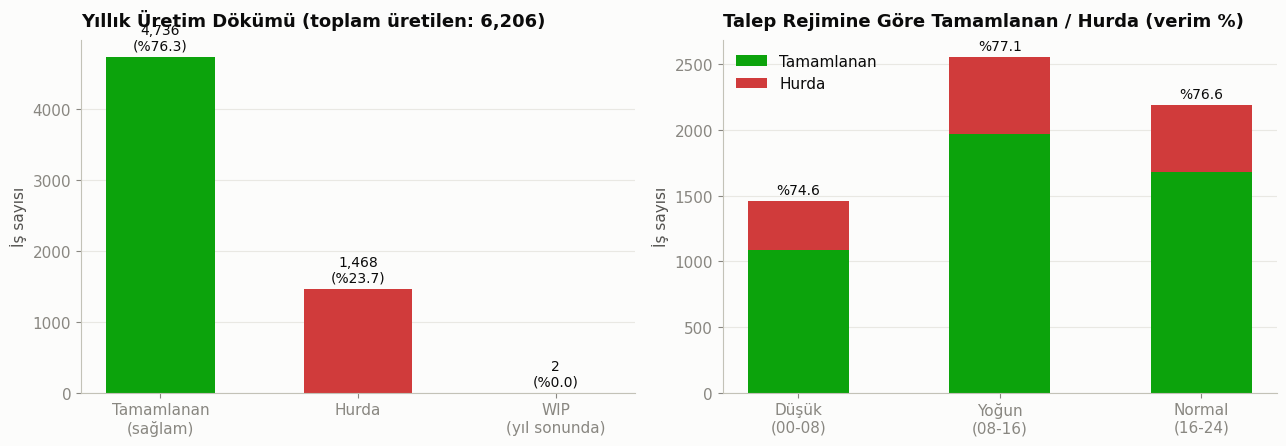

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# Sol: yillik uretim dokumu -- uretilen -> tamamlanan / hurda / WIP
labels = ["Tamamlanan\n(sağlam)", "Hurda", "WIP\n(yıl sonunda)"]
values = [annual_metrics["completed_jobs"], annual_metrics["scrapped_jobs"], annual_metrics["wip_at_horizon"]]
colors = [STATUS["good"], STATUS["critical"], CATEGORICAL[3]]
bars = axes[0].bar(labels, values, color=colors, width=0.55)
for b, v in zip(bars, values):
    pct = 100 * v / annual_metrics["generated_jobs"]
    axes[0].text(b.get_x() + b.get_width()/2, v + max(values)*0.02, f"{v:,}\n(%{pct:.1f})", ha="center", fontsize=10)
style_ax(axes[0], f"Yıllık Üretim Dökümü (toplam üretilen: {annual_metrics['generated_jobs']:,})", None, "İş sayısı")

# Sag: talep rejimine gore tamamlanan/hurda dagilimi (WIP haric -- sadece ~2 is, ihmal edilebilir)
regime_order = ["LOW", "PEAK", "NORMAL"]
comp = [int(((df_annual.arrival_regime == r) & (df_annual.status == "completed")).sum()) for r in regime_order]
scr = [int(((df_annual.arrival_regime == r) & (df_annual.status != "completed")).sum()) for r in regime_order]
x = np.arange(len(regime_order))
axes[1].bar(x, comp, color=STATUS["good"], width=0.5, label="Tamamlanan")
axes[1].bar(x, scr, bottom=comp, color=STATUS["critical"], width=0.5, label="Hurda")
max_total = max(c + s for c, s in zip(comp, scr))
for i in range(len(regime_order)):
    total = comp[i] + scr[i]
    yield_r = 100 * comp[i] / total if total else float("nan")
    axes[1].text(i, total + max_total*0.02, f"%{yield_r:.1f}", ha="center", fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(["Düşük\n(00-08)", "Yoğun\n(08-16)", "Normal\n(16-24)"])
style_ax(axes[1], "Talep Rejimine Göre Tamamlanan / Hurda (verim %)", None, "İş sayısı")
axes[1].legend()

fig.tight_layout()
plt.show()

In [ ]:
import numpy as np

rows = []
for name in ["M1", "M2", "M3"]:
    s = machine_stats[name]
    total_check = s["processing_time"] + s["repair_time"] + s["blocked_time"] + s["idle_time"]
    assert np.isclose(total_check, ANNUAL_HORIZON_MIN), f"{name}: {total_check} != {ANNUAL_HORIZON_MIN}"
    rows.append({
        "Makine": name,
        "İşlem %": s["productive_utilization_pct"],
        "Onarım %": s["repair_downtime_pct"],
        "Bloke %": s["blocked_pct"],
        "Boşta %": s["idle_pct"],
        "Toplam (dk)": total_check,
    })

machine_time_df = pd.DataFrame(rows).set_index("Makine")
print(f"(Her satırın toplamı ANNUAL_HORIZON_MIN={ANNUAL_HORIZON_MIN:,} dk'ya eşit olmalı -- yukarıdaki assert bunu doğruladı)\n")
machine_time_df.round(2)

(Her satırın toplamı ANNUAL_HORIZON_MIN=525,600 dk'ya eşit olmalı -- yukarıdaki assert bunu doğruladı)



,İşlem %,Onarım %,Bloke %,Boşta %,Toplam (dk)
Makine,,,,,
M1,36.95,5.35,0.0,57.70,525600.0
M2,45.36,4.65,0.0,49.99,525600.0
M3,72.57,8.83,0.0,18.61,525600.0


**Not:** rejim, sadece her yeni iş üretilirken
`env.now % 1440` ile kontrol ediliyor, sürekli yeniden örneklenmiyor).

### 4.5 Makine Bazında Yıllık Zaman Muhasebesi



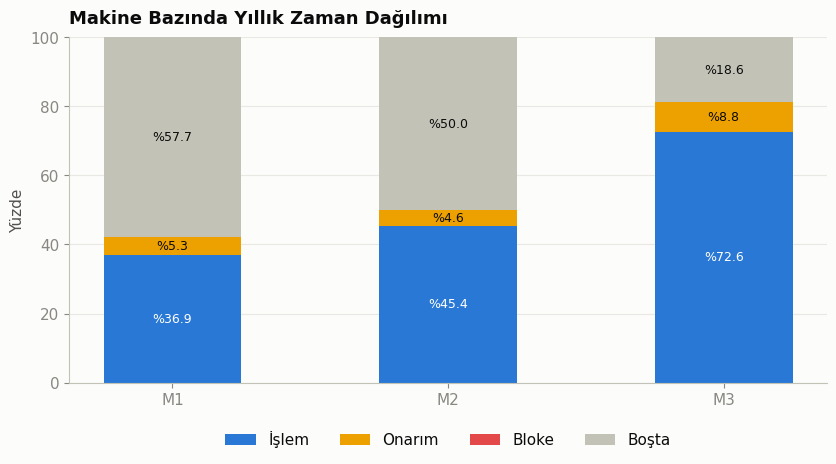

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
machines = ["M1", "M2", "M3"]
proc = [machine_stats[m]["productive_utilization_pct"] for m in machines]
rep = [machine_stats[m]["repair_downtime_pct"] for m in machines]
blk = [machine_stats[m]["blocked_pct"] for m in machines]
idl = [machine_stats[m]["idle_pct"] for m in machines]

x = np.arange(len(machines))
bottom1 = proc
bottom2 = [a + b for a, b in zip(proc, rep)]
bottom3 = [a + b for a, b in zip(bottom2, blk)]
ax.bar(x, proc, color=CATEGORICAL[0], width=0.5, label="İşlem")
ax.bar(x, rep, bottom=bottom1, color=CATEGORICAL[3], width=0.5, label="Onarım")
ax.bar(x, blk, bottom=bottom2, color=CATEGORICAL[7], width=0.5, label="Bloke")
ax.bar(x, idl, bottom=bottom3, color=BASELINE, width=0.5, label="Boşta")

for i in range(len(machines)):
    cum = 0.0
    for val, name in zip([proc[i], rep[i], blk[i], idl[i]], ["İşlem", "Onarım", "Bloke", "Boşta"]):
        if val > 3:
            txt_color = "white" if name in ("İşlem", "Bloke") else INK
            ax.text(i, cum + val/2, f"%{val:.1f}", ha="center", va="center", fontsize=9, color=txt_color)
        cum += val

ax.set_xticks(x)
ax.set_xticklabels(machines)
ax.set_ylim(0, 100)
style_ax(ax, "Makine Bazında Yıllık Zaman Dağılımı", None, "Yüzde")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4)
fig.tight_layout()
plt.show()

### 4.6 Normal Hız ile Adaptif Hız: Yıllık Sağlam Üretim Karşılaştırması

Aynı yıllık/dinamik-talep senaryosu, iki hız politikasıyla (yönlendirme yine rastgele %50/%50,
`seed=42`): `policy_fn=None` (hep normal hız) ve `heuristic_speedup_policy` (Bölüm 2.6 — kendi
kuyruğu eşiği aşan istasyon hızlanır).

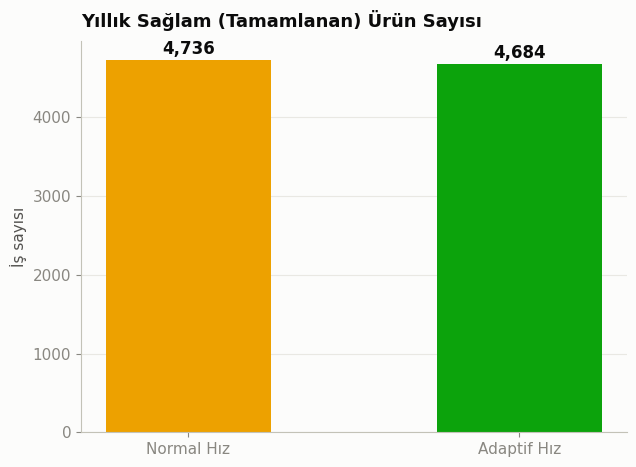

In [ ]:
_, annual_metrics_normal, _ = run_annual_simulation(seed=42, policy_fn=None)
_, annual_metrics_adaptive, _ = run_annual_simulation(seed=42, policy_fn=heuristic_speedup_policy)

labels = ["Normal Hız", "Adaptif Hız"]
values = [annual_metrics_normal["completed_jobs"], annual_metrics_adaptive["completed_jobs"]]
colors = [CATEGORICAL[3], STATUS["good"]]

fig, ax = plt.subplots(figsize=(6.5, 4.8))
bars = ax.bar(labels, values, color=colors, width=0.5)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + max(values)*0.015, f"{v:,}", ha="center", fontsize=12, fontweight="bold")
style_ax(ax, "Yıllık Sağlam (Tamamlanan) Ürün Sayısı", None, "İş sayısı")
fig.tight_layout()
plt.show()

## 5. Pekiştirmeli Öğrenme (Q-Learning): Hız + Yönlendirme + Bakım Kararı



1. **Yönlendirme:** yeni bir iş geldiğinde M1'e mi M2'ye mi gitsin?
2. **Hız:** bir istasyon işlemeye başlarken yavaş/normal/hızlı mı çalışsın?
3. **Bakım (YENİ aksiyon):** işlemeye başlamadan önce, aşınma yeterince yüksekse önce planlı
   bakıma mı girsin?



### 5.1 Yeni Aksiyon: Bakım (VARSAYIM)



In [ ]:
RL_PARAMS = dict(DEFAULT_PARAMS)     # Bolum 2'nin TUM parametreleri aynen korunuyor
RL_PARAMS["MAINT_MIN"] = 20          # VARSAYIM: planli bakim suresi (veride yok)
RL_PARAMS["MAINT_MAX"] = 35          # VARSAYIM -- REPAIR_MIN/MAX'tan (45/90) bilinCli olarak daha kisa
MAINT_ACTION = 3                     # aksiyon uzayi: 0=yavas,1=normal,2=hizli,3=bakim

def reward_components_rl(action, t, own_q_after, failed_now, repair_time, maint_time, p):
    # Bolum 2'nin reward_components'iyla AYNI yapi/agirliklar -- tek fark: bakim suresi de
    # (maint_time) bir "sure maliyeti" olarak r_time'a ekleniyor, yeni bir agirlik EKLENMEDI.
    r_time = -p["W_TIME"] * (t + maint_time)
    r_queue = -p["W_QUEUE"] * own_q_after
    r_fail = -(p["W_FAIL"] + p["W_REPAIR"] * repair_time) if failed_now else 0.0
    r_energy = -p["W_ENERGY"] if action == 2 else 0.0
    return r_time + r_queue + r_fail + r_energy

print(f"MAINT_MIN={RL_PARAMS['MAINT_MIN']} dk, MAINT_MAX={RL_PARAMS['MAINT_MAX']} dk "
      f"(karşılaştırma: REPAIR_MIN={RL_PARAMS['REPAIR_MIN']}, REPAIR_MAX={RL_PARAMS['REPAIR_MAX']} dk)")

MAINT_MIN=20 dk, MAINT_MAX=35 dk (karşılaştırma: REPAIR_MIN=45, REPAIR_MAX=90 dk)


### 5.2 Durum Uzayı, Q-Tabloları ve Ödül


In [ ]:
def wear_bin(w):
    if w <= 4: return 0
    if w <= 9: return 1
    return 2

def queue_bin(q):
    if q == 0: return 0
    if q <= 2: return 1
    if q <= 5: return 2
    return 3

WEAR_CAP_, QUEUE_CAP_, BUFFER_CAP_ = DEFAULT_PARAMS["WEAR_CAP"], DEFAULT_PARAMS["QUEUE_CAP"], DEFAULT_PARAMS["BUFFER_CAP"]
STATION_Q_SHAPE = (WEAR_CAP_ + 1, QUEUE_CAP_ + 1, BUFFER_CAP_ + 1, 3, 4)
ROUTING_Q_SHAPE = (4, 4, 3, 3, 2)
print(f"İstasyon Q-tablosu: {STATION_Q_SHAPE} = {np.prod(STATION_Q_SHAPE):,} (durum,aksiyon) çifti")
print(f"Yönlendirme Q-tablosu: {ROUTING_Q_SHAPE} = {np.prod(ROUTING_Q_SHAPE):,} (durum,aksiyon) çifti")


def make_station_eps_greedy(q_table, epsilon, explore_rng):
    def policy_fn(state):
        if explore_rng.random() < epsilon:
            return explore_rng.choice([0, 1, 2, 3])
        return int(np.argmax(q_table[state]))
    return policy_fn

def make_station_greedy(q_table, visit_counts):
    def policy_fn(state):
        if visit_counts[state].sum() == 0:
            return 1   # hic ziyaret edilmemis durumda notr aksiyona (normal) don
        return int(np.argmax(q_table[state]))
    return policy_fn

def make_routing_eps_greedy(q_table, epsilon, explore_rng):
    def routing_fn(raw_state):
        m1_q, m2_q, m1_wear, m2_wear = raw_state
        key = (queue_bin(m1_q), queue_bin(m2_q), wear_bin(m1_wear), wear_bin(m2_wear))
        if explore_rng.random() < epsilon:
            return explore_rng.choice([0, 1])
        return int(np.argmax(q_table[key]))
    return routing_fn

def make_routing_greedy(q_table, visit_counts):
    def routing_fn(raw_state):
        m1_q, m2_q, m1_wear, m2_wear = raw_state
        key = (queue_bin(m1_q), queue_bin(m2_q), wear_bin(m1_wear), wear_bin(m2_wear))
        if visit_counts[key].sum() == 0:
            return random.choice([0, 1])
        return int(np.argmax(q_table[key]))
    return routing_fn

İstasyon Q-tablosu: (16, 9, 6, 3, 4) = 10,368 (durum,aksiyon) çifti
Yönlendirme Q-tablosu: (4, 4, 3, 3, 2) = 288 (durum,aksiyon) çifti


### 5.3 Motor: Bölüm 4'ün Aynısı + Bakım Aksiyonu + Ödül Kaydı

`parallel_station_process_rl`/`m3_loop_process_rl`/`job_proc_rl`/`job_generator_rl`, Bölüm 4'ün
`_annual` fonksiyonlarının **birebir aynı fiziği** (dinamik talep, sonlu tampon, hurda mantığı)
— eklenen: (a) aksiyon `MAINT_ACTION` ise işlem başlamadan önce bakım arası, (b) her kararın
durumu/aksiyonu/ödülü/karar-zamanı satıra kaydediliyor (eğitim için gerekli), (c) yönlendirme
kararı da aynı şekilde kaydediliyor.

In [ ]:
class MachineStateTrackerRL:
    # Bolum 4.2'nin MachineStateTracker'iyla AYNI mantik -- TEK fark: planli BAKIM artik
    # "repair" (plansiz onarim) kovasina degil, ayri bir "maintenance" kovasina yaziliyor.
    def __init__(self, env, name):
        self.env = env
        self.name = name
        self.current_state = "idle"
        self.state_start = env.now
        self.totals = {"processing": 0.0, "repair": 0.0, "maintenance": 0.0, "blocked": 0.0, "idle": 0.0}

    def set_state(self, new_state):
        now = self.env.now
        self.totals[self.current_state] += (now - self.state_start)
        self.current_state = new_state
        self.state_start = now

    def finalize(self, horizon):
        self.totals[self.current_state] += (horizon - self.state_start)
        self.current_state = None


def parallel_station_process_rl(env, station_name, station_id, resource, buffer, row, tracker,
                                 wear_state, rng, policy_fn, p, station_visit_counts=None):
    queue_join_time = env.now
    with resource.request() as req:
        yield req
        wait = env.now - queue_join_time
        own_q = len(resource.queue)
        buf_len = len(buffer.items)
        wear = wear_state[station_name]

        maint_time = 0.0
        state = (wear, min(own_q, p["QUEUE_CAP"]), min(buf_len, p["BUFFER_CAP"]), station_id)
        action = policy_fn(state) if policy_fn is not None else 1
        if station_visit_counts is not None:
            station_visit_counts[state + (action,)] += 1

        if action == MAINT_ACTION:
            tracker.set_state("maintenance")   # onarimdan AYRI kova -- bkz. bu hucrenin basindaki MachineStateTrackerRL
            maint_time = rng.uniform(p["MAINT_MIN"], p["MAINT_MAX"])
            yield env.timeout(maint_time)
            wear = 0
            wear_state[station_name] = 0

        proc_min, proc_max = get_proc_range(station_name, p)
        proc_action = 1 if action == MAINT_ACTION else action   # bakim sonrasi islem NORMAL hizda
        tracker.set_state("processing")
        t = rng.uniform(proc_min, proc_max) * p["SPEED_MULT"][proc_action]
        wear_slope = get_wear_slope(station_name, p)
        p_fail_eff = min(p["BASE_FAIL"] + wear_slope * wear, p["MAX_FAIL"])
        failed_now = rng.random() < p_fail_eff

        yield env.timeout(t)

        repair_time = 0.0
        if failed_now:
            tracker.set_state("repair")
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)
            new_wear = 0
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][proc_action])
        wear_state[station_name] = new_wear
        own_q_after = len(resource.queue)

        block_time = 0.0
        if not failed_now:
            tracker.set_state("blocked")
            block_start = env.now
            yield buffer.put(row)
            block_time = env.now - block_start
            row["buffer_enter_time"] = env.now

        tracker.set_state("idle")

    row[f"{station_name}_action"] = action
    row[f"{station_name}_failed"] = failed_now
    row[f"{station_name}_state"] = state
    row[f"{station_name}_reward"] = reward_components_rl(proc_action, t, own_q_after, failed_now, repair_time, maint_time, p)
    row[f"{station_name}_decision_time"] = queue_join_time + wait
    row[f"{station_name}_wait"] = wait
    row[f"{station_name}_maint_time"] = maint_time

    if failed_now:
        row["status"] = f"failed_{station_name}"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
    return failed_now


def m3_loop_process_rl(env, buffer, tracker, wear_state, rng, policy_fn, p, log, station_visit_counts=None):
    while True:
        row = yield buffer.get()
        row["buffer_wait_time"] = env.now - row["buffer_enter_time"]
        own_q = len(buffer.items)
        wear = wear_state["M3"]

        maint_time = 0.0
        state = (wear, min(own_q, p["QUEUE_CAP"]), 0, 2)
        action = policy_fn(state) if policy_fn is not None else 1
        if station_visit_counts is not None:
            station_visit_counts[state + (action,)] += 1

        if action == MAINT_ACTION:
            tracker.set_state("maintenance")   # onarimdan AYRI kova
            maint_time = rng.uniform(p["MAINT_MIN"], p["MAINT_MAX"])
            yield env.timeout(maint_time)
            wear = 0
            wear_state["M3"] = 0

        proc_action = 1 if action == MAINT_ACTION else action
        tracker.set_state("processing")
        t = rng.uniform(p["PROC_MIN"], p["PROC_MAX"]) * p["SPEED_MULT"][proc_action]
        p_fail_eff = min(p["BASE_FAIL"] + p["WEAR_SLOPE"] * wear, p["MAX_FAIL"])
        failed_now = rng.random() < p_fail_eff
        yield env.timeout(t)

        repair_time = 0.0
        if failed_now:
            tracker.set_state("repair")
            repair_time = rng.uniform(p["REPAIR_MIN"], p["REPAIR_MAX"])
            yield env.timeout(repair_time)
            new_wear = 0
        else:
            new_wear = min(p["WEAR_CAP"], wear + p["WEAR_DELTA"][proc_action])
        wear_state["M3"] = new_wear
        tracker.set_state("idle")

        row["M3_action"] = action
        row["M3_failed"] = failed_now
        row["M3_state"] = state
        row["M3_reward"] = reward_components_rl(proc_action, t, own_q, failed_now, repair_time, maint_time, p)
        row["M3_decision_time"] = env.now
        row["M3_maint_time"] = maint_time
        row["status"] = "failed_M3" if failed_now else "completed"
        row["leave"] = env.now
        row["flow_time"] = row["leave"] - row["arrive"]
        log.append(row)


def job_proc_rl(env, row, m1, m2, buffer, log, wear_state, trackers, rng, routing_fn, policy_fn, p,
                 station_visit_counts=None, routing_visit_counts=None):
    outcome_pre = sample_outcome_pre(rng, p)
    release_delay = 0.0
    if outcome_pre == "Delayed":
        release_delay = rng.uniform(p["DELAY_MIN"], p["DELAY_MAX"])
        yield env.timeout(release_delay)
    row["release_delay"] = release_delay

    routing_raw = (len(m1.queue), len(m2.queue), wear_state["M1"], wear_state["M2"])
    chosen = routing_fn(routing_raw) if routing_fn is not None else rng.choice([0, 1])
    row["routed_to"] = "M1" if chosen == 0 else "M2"
    row["routing_state"] = routing_raw
    row["routing_action"] = chosen
    if routing_visit_counts is not None:
        m1_q, m2_q, m1_w, m2_w = routing_raw
        routing_visit_counts[(queue_bin(m1_q), queue_bin(m2_q), wear_bin(m1_w), wear_bin(m2_w), chosen)] += 1

    if chosen == 0:
        failed = yield from parallel_station_process_rl(env, "M1", 0, m1, buffer, row, trackers["M1"],
                                                          wear_state, rng, policy_fn, p, station_visit_counts)
    else:
        failed = yield from parallel_station_process_rl(env, "M2", 1, m2, buffer, row, trackers["M2"],
                                                          wear_state, rng, policy_fn, p, station_visit_counts)
    if failed:
        log.append(row)


def job_generator_rl(env, m1, m2, buffer, log, all_jobs_registry, wear_state, trackers, rng,
                      routing_fn, policy_fn, p, station_visit_counts=None, routing_visit_counts=None):
    counter = 0
    while True:
        regime = get_demand_regime(env.now)
        interarrival = INTERARRIVAL_BY_REGIME[regime]
        counter += 1
        name = f"Is-{counter}"
        row = {"name": name, "arrive": env.now, "arrival_regime": regime}
        all_jobs_registry[name] = row
        env.process(job_proc_rl(env, row, m1, m2, buffer, log, wear_state, trackers, rng,
                                 routing_fn, policy_fn, p, station_visit_counts, routing_visit_counts))
        yield env.timeout(interarrival)


def run_episode_rl(horizon, seed, routing_fn, policy_fn, p, station_visit_counts=None, routing_visit_counts=None):
    rng = random.Random(seed)
    env = simpy.Environment()
    m1 = simpy.Resource(env, capacity=1)
    m2 = simpy.Resource(env, capacity=1)
    buffer = simpy.Store(env, capacity=p["BUFFER_CAP"])
    wear_state = {"M1": 0, "M2": 0, "M3": 0}
    log, all_jobs_registry = [], {}
    trackers = {name: MachineStateTrackerRL(env, name) for name in ["M1", "M2", "M3"]}
    env.process(job_generator_rl(env, m1, m2, buffer, log, all_jobs_registry, wear_state, trackers,
                                  rng, routing_fn, policy_fn, p, station_visit_counts, routing_visit_counts))
    env.process(m3_loop_process_rl(env, buffer, trackers["M3"], wear_state, rng, policy_fn, p, log, station_visit_counts))
    env.run(until=horizon)
    for tr in trackers.values():
        tr.finalize(horizon)
    return log, all_jobs_registry, trackers


def compute_metrics_rl(log, all_jobs_registry, horizon):
    df = pd.DataFrame(log).sort_values("arrive").reset_index(drop=True) if log else pd.DataFrame()
    generated_jobs = len(all_jobs_registry)
    completed_jobs = int((df["status"] == "completed").sum()) if len(df) else 0
    scrapped_jobs = int((df["status"] != "completed").sum()) if len(df) else 0
    wip_at_horizon = generated_jobs - len(df)
    assert generated_jobs == completed_jobs + scrapped_jobs + wip_at_horizon
    yield_pct = 100 * completed_jobs / (completed_jobs + scrapped_jobs) if (completed_jobs + scrapped_jobs) > 0 else float("nan")
    return df, {"generated_jobs": generated_jobs, "completed_jobs": completed_jobs,
                "scrapped_jobs": scrapped_jobs, "wip_at_horizon": wip_at_horizon, "yield_pct": yield_pct}


def run_annual_simulation_rl(seed=42, routing_fn=None, policy_fn=None, params=None):
    p = params if params is not None else RL_PARAMS
    log, reg, trackers = run_episode_rl(ANNUAL_HORIZON_MIN, seed, routing_fn, policy_fn, p)
    df, m = compute_metrics_rl(log, reg, ANNUAL_HORIZON_MIN)
    return df, m, trackers

### 5.4 Bellman

In [ ]:
def bellman_update_stations(log, q_table, update_counts, alpha_init, alpha_min, gamma):
    for station_name in ("M1", "M2", "M3"):
        st_key, ac_key, dt_key = f"{station_name}_state", f"{station_name}_action", f"{station_name}_decision_time"
        chain = sorted([r for r in log if r.get(dt_key) is not None], key=lambda r: r[dt_key])
        n = len(chain)
        for i in range(n):
            row = chain[i]
            s, a, r = row[st_key], row[ac_key], row[f"{station_name}_reward"]
            idx = s + (a,)
            target = r + gamma * np.max(q_table[chain[i + 1][st_key]]) if i < n - 1 else r
            update_counts[idx] += 1
            alpha_sa = max(alpha_min, alpha_init / np.sqrt(update_counts[idx]))
            q_table[idx] += alpha_sa * (target - q_table[idx])


def routing_reward(row, p):
    W_FAIL_ROUTE, W_TIME_ROUTE = 1.0, 1.0 / 500.0
    flow_time = row.get("flow_time", 0.0) or 0.0
    r_fail = -W_FAIL_ROUTE if row.get("status") != "completed" else 0.0
    r_time = -W_TIME_ROUTE * flow_time
    return r_fail + r_time


def bellman_update_routing(log, q_table, update_counts, alpha_init, alpha_min, p):
    for row in log:
        if row.get("routing_state") is None or row.get("status") is None:
            continue
        m1_q, m2_q, m1_w, m2_w = row["routing_state"]
        key = (queue_bin(m1_q), queue_bin(m2_q), wear_bin(m1_w), wear_bin(m2_w), row["routing_action"])
        r = routing_reward(row, p)
        update_counts[key] += 1
        alpha_sa = max(alpha_min, alpha_init / np.sqrt(update_counts[key]))
        q_table[key] += alpha_sa * (r - q_table[key])

ALPHA_INITIAL, ALPHA_MIN, GAMMA = 0.5, 0.03, 0.95
EPSILON_START, EPSILON_END, EPSILON_DECAY = 1.0, 0.05, 0.995
print(f"alpha_init={ALPHA_INITIAL} alpha_min={ALPHA_MIN} gamma={GAMMA}  |  "
      f"epsilon: {EPSILON_START}->{EPSILON_END} (çarpan={EPSILON_DECAY}/bölüm)")

alpha_init=0.5 alpha_min=0.03 gamma=0.95  |  epsilon: 1.0->0.05 (çarpan=0.995/bölüm)


### 5.5 Eğitim: 10 Tohum, Sabit-Süreli Bölümler, Holdout Yakınsama Kontrolü

Her eğitim tohumu **kendi** Q-tablolarını sıfırdan öğreniyor. Bölümler **tam bir yıl değil**,
sabit **15 günlük** pencereler (`TRAIN_HORIZON_MIN`) — yıllık ufuk (`ANNUAL_HORIZON_MIN`) SADECE
5.7'deki tek seferlik resmi karşılaştırma için ayrılıyor, eğitim/model-seçim sürecinde HİÇ
kullanılmıyor. Öğrenmenin platoya ulaşıp ulaşmadığını, eğitimde HİÇ görülmeyen sabit
`VALID_SEEDS`'te, 30 günlük bir pencerede (`VALIDATION_HORIZON_MIN`), **açgözlü (ε=0)**
politikayla periyodik olarak ölçerek kontrol ediyoruz.

In [ ]:
TRAIN_HORIZON_MIN = 15 * 24 * 60
VALIDATION_HORIZON_MIN = 30 * 24 * 60   # yakinsama kontrolu + ajan secimi penceresi
TRAIN_SEEDS = list(range(10))
VALID_SEEDS = [9001, 9002, 9003]
N_EPISODES = 1500

def train_one_agent(train_seed):
    station_q = np.zeros(STATION_Q_SHAPE); station_uc = np.zeros(STATION_Q_SHAPE, dtype=int)
    station_vc = np.zeros(STATION_Q_SHAPE, dtype=int)
    routing_q = np.zeros(ROUTING_Q_SHAPE); routing_uc = np.zeros(ROUTING_Q_SHAPE, dtype=int)
    routing_vc = np.zeros(ROUTING_Q_SHAPE, dtype=int)
    explore_rng = random.Random(train_seed * 7919 + 1)
    epsilon = EPSILON_START
    curve = []
    for ep in range(N_EPISODES):
        pf = make_station_eps_greedy(station_q, epsilon, explore_rng)
        rf = make_routing_eps_greedy(routing_q, epsilon, explore_rng)
        log, reg, _ = run_episode_rl(TRAIN_HORIZON_MIN, seed=train_seed * 100000 + ep, routing_fn=rf, policy_fn=pf,
                                      p=RL_PARAMS, station_visit_counts=station_vc, routing_visit_counts=routing_vc)
        bellman_update_stations(log, station_q, station_uc, ALPHA_INITIAL, ALPHA_MIN, GAMMA)
        bellman_update_routing(log, routing_q, routing_uc, ALPHA_INITIAL, ALPHA_MIN, RL_PARAMS)
        epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)
        if ep % 200 == 0 or ep == N_EPISODES - 1:
            gpf, grf = make_station_greedy(station_q, station_vc), make_routing_greedy(routing_q, routing_vc)
            vals = []
            for vs in VALID_SEEDS:
                log2, reg2, _ = run_episode_rl(VALIDATION_HORIZON_MIN, vs, grf, gpf, RL_PARAMS)
                _, m2 = compute_metrics_rl(log2, reg2, VALIDATION_HORIZON_MIN)
                vals.append(m2["completed_jobs"])
            curve.append((ep, float(np.mean(vals))))
    return station_q, station_vc, routing_q, routing_vc, curve


print(f"{len(TRAIN_SEEDS)} tohum x {N_EPISODES} bölüm eğitim başlıyor (TRAIN_HORIZON_MIN={TRAIN_HORIZON_MIN} dk/bölüm)...")
t0 = time.time()
trained_agents = [train_one_agent(ts) for ts in TRAIN_SEEDS]
print(f"Eğitim bitti ({time.time()-t0:.0f} sn).")

10 tohum x 1500 bölüm eğitim başlıyor (TRAIN_HORIZON_MIN=21600 dk/bölüm)...
Eğitim bitti (393 sn).


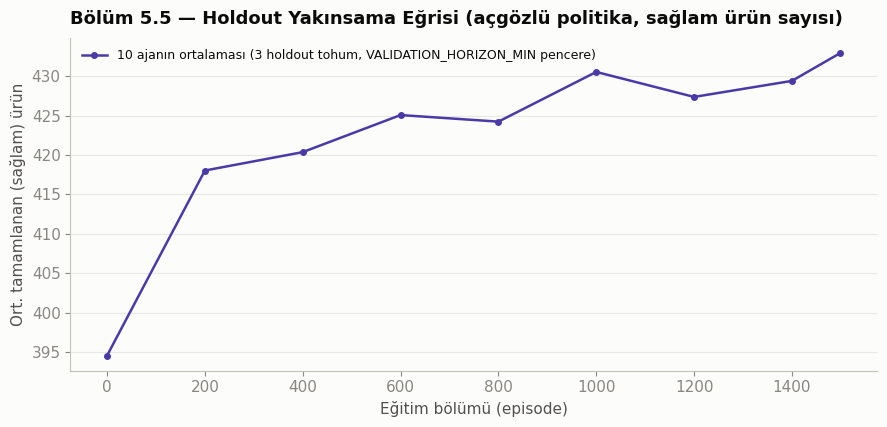

İlk kontrol noktası (bölüm 0): 394.6
Son kontrol noktası (bölüm 1499): 432.9
Son 3 kontrol noktasının std'si: 2.30 (küçükse -> plato, 1500 bölüm yeterli)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.4))
all_eps = [ep for ep, _ in trained_agents[0][4]]
curve_matrix = np.array([[v for _, v in agent[4]] for agent in trained_agents])
mean_curve = curve_matrix.mean(axis=0)
ax.plot(all_eps, mean_curve, color=CATEGORICAL[6], marker="o", markersize=4, linewidth=1.8,
        label=f"{len(TRAIN_SEEDS)} ajanın ortalaması ({len(VALID_SEEDS)} holdout tohum, VALIDATION_HORIZON_MIN pencere)")
style_ax(ax, "Bölüm 5.5 — Holdout Yakınsama Eğrisi (açgözlü politika, sağlam ürün sayısı)",
         "Eğitim bölümü (episode)", "Ort. tamamlanan (sağlam) ürün")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"İlk kontrol noktası (bölüm {all_eps[0]}): {mean_curve[0]:.1f}")
print(f"Son kontrol noktası (bölüm {all_eps[-1]}): {mean_curve[-1]:.1f}")
print(f"Son 3 kontrol noktasının std'si: {mean_curve[-3:].std():.2f} (küçükse -> plato, {N_EPISODES} bölüm yeterli)")

### 5.6 Kısıtlı Olmayan, Basit Ajan Seçimi

10 ajanın her biri, `VALID_SEEDS` üzerinde açgözlü politikayla değerlendirilip **en yüksek
ortalama tamamlanan (sağlam) ürün sayısına** sahip olan seçiliyor — bu, kullanıcının orijinal
hedefiyle (hurda/duruş sınırlarını aşmadan daha fazla sağlam ürün) doğrudan hizalı. **Not:**
eski (iki-istasyonlu) modeldeki daha gelişmiş, kısıt-tabanlı (`SCRAP_RATE_LIMIT`/`DOWNTIME_LIMIT`)
seçim mekanizmasının **basitleştirilmiş** bir hali — burada tek kriter kullanılıyor. Seçim,
resmi N=30 tohumlu karşılaştırmaya (5.8) hiç bakılmadan yapılıyor.

In [ ]:
agent_scores = []
for i, (sq, svc, rq, rvc, curve) in enumerate(trained_agents):
    gpf, grf = make_station_greedy(sq, svc), make_routing_greedy(rq, rvc)
    vals = []
    for vs in VALID_SEEDS:
        log2, reg2, _ = run_episode_rl(VALIDATION_HORIZON_MIN, vs, grf, gpf, RL_PARAMS)
        _, m2 = compute_metrics_rl(log2, reg2, VALIDATION_HORIZON_MIN)
        vals.append(m2["completed_jobs"])
    agent_scores.append(float(np.mean(vals)))

best_idx = int(np.argmax(agent_scores))
print("Ajan başına holdout ortalaması (tamamlanan sağlam ürün):")
for i, sc in enumerate(agent_scores):
    marker = "  <-- SEÇİLEN" if i == best_idx else ""
    print(f"  train_seed={TRAIN_SEEDS[i]:2d}  holdout_ort={sc:7.1f}{marker}")

best_station_q, best_station_vc, best_routing_q, best_routing_vc, _ = trained_agents[best_idx]
RL_POLICY_FN = make_station_greedy(best_station_q, best_station_vc)
RL_ROUTING_FN = make_routing_greedy(best_routing_q, best_routing_vc)

Ajan başına holdout ortalaması (tamamlanan sağlam ürün):
  train_seed= 0  holdout_ort=  415.0
  train_seed= 1  holdout_ort=  432.0
  train_seed= 2  holdout_ort=  424.7
  train_seed= 3  holdout_ort=  434.0
  train_seed= 4  holdout_ort=  438.0
  train_seed= 5  holdout_ort=  436.0
  train_seed= 6  holdout_ort=  445.0  <-- SEÇİLEN
  train_seed= 7  holdout_ort=  434.3
  train_seed= 8  holdout_ort=  438.0
  train_seed= 9  holdout_ort=  432.3


### 5.7 Bakım Süresinin Onarımdan Ayrıştırılması (Doğrulama)

In [ ]:
_, _, _trackers = run_annual_simulation_rl(seed=42, routing_fn=RL_ROUTING_FN, policy_fn=RL_POLICY_FN, params=RL_PARAMS)
_rows = []
for mach, tr in _trackers.items():
    tot = tr.totals
    total_check = tot["processing"] + tot["repair"] + tot["maintenance"] + tot["blocked"] + tot["idle"]
    assert np.isclose(total_check, ANNUAL_HORIZON_MIN), f"{mach}: {total_check} != {ANNUAL_HORIZON_MIN}"
    _rows.append({"Makine": mach, "Onarım (dk)": tot["repair"],
                   "Bakım (dk)": tot["maintenance"], "Toplam (dk)": total_check})

_verify_df = pd.DataFrame(_rows).set_index("Makine")
print(f"(RL, seed=42 -- her satırın 5 bileşeni -- işlem/onarım/bakım/bloke/boşta -- toplamda "
      f"ANNUAL_HORIZON_MIN={ANNUAL_HORIZON_MIN:,} dk'ya eşit; assert bunu doğruladı; onarım ve bakım AYRI sütun.)\n")
_verify_df.round(1)

(RL, seed=42 -- her satırın 5 bileşeni -- işlem/onarım/bakım/bloke/boşta -- toplamda ANNUAL_HORIZON_MIN=525,600 dk'ya eşit; assert bunu doğruladı; onarım ve bakım AYRI sütun.)



,Onarım (dk),Bakım (dk),Toplam (dk)
Makine,,,
M1,6776.0,9477.5,525600.0
M2,16651.0,52429.3,525600.0
M3,23238.2,51433.8,525600.0


### 5.8 Resmi Karşılaştırma: Normal Hız vs Adaptif Hız vs RL (N=30 Tohum)

N=30 tohum x 3 politika değerlendirmesi 40 sn sürdü.

             Ort. Verim %  Std Verim %  Ort. Tamamlanan  Std Tamamlanan
Politika                                                               
Normal Hız          75.71         0.33          4696.17           20.52
Adaptif Hız         75.36         0.42          4674.73           26.40
RL                  88.16         0.41          5468.00           25.32

(Bilgi -- seed=42 tekil sonuç: Normal=4736, Adaptif=4684 -- Bölüm 4.6'daki 4736/4684 ile tutarlı olmalı, çünkü aynı fizik/rng sırası, sadece motor farklı.)


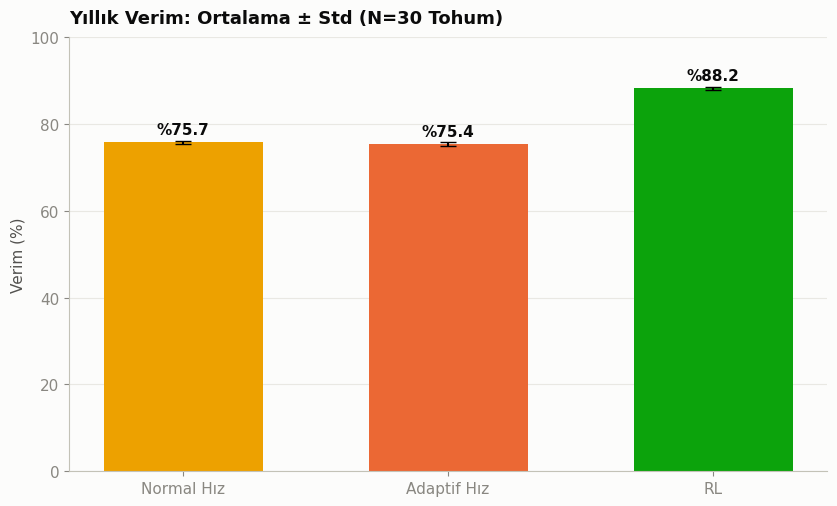

In [ ]:
EVAL_SEEDS = [42] + list(range(101, 130))   # N=30
POLICIES = [
    ("Normal Hız",       None,                          None),
    ("Adaptif Hız",      heuristic_speedup_policy,       None),
    ("RL",               RL_POLICY_FN,                   RL_ROUTING_FN),
]

results = {name: {"yield": [], "completed": [], "scrapped": []} for name, _, _ in POLICIES}
t0 = time.time()
for seed in EVAL_SEEDS:
    for name, pf, rf in POLICIES:
        _, m, _ = run_annual_simulation_rl(seed=seed, routing_fn=rf, policy_fn=pf, params=RL_PARAMS)
        results[name]["yield"].append(m["yield_pct"])
        results[name]["completed"].append(m["completed_jobs"])
        results[name]["scrapped"].append(m["scrapped_jobs"])
print(f"N={len(EVAL_SEEDS)} tohum x {len(POLICIES)} politika değerlendirmesi {time.time()-t0:.0f} sn sürdü.\n")

_summary_rows = []
for name, _, _ in POLICIES:
    y, c = np.array(results[name]["yield"]), np.array(results[name]["completed"])
    _summary_rows.append({"Politika": name, "Ort. Verim %": y.mean(), "Std Verim %": y.std(),
                           "Ort. Tamamlanan": c.mean(), "Std Tamamlanan": c.std()})
summary_df = pd.DataFrame(_summary_rows).set_index("Politika")
print(summary_df.round(2))

print(f"\n(Bilgi -- seed=42 tekil sonuç: Normal={results['Normal Hız']['completed'][0]}, "
      f"Adaptif={results['Adaptif Hız']['completed'][0]} -- Bölüm 4.6'daki 4736/4684 ile tutarlı olmalı, "
      f"çünkü aynı fizik/rng sırası, sadece motor farklı.)")

labels = [name for name, _, _ in POLICIES]
means = [summary_df.loc[n, "Ort. Verim %"] for n in labels]
stds = [summary_df.loc[n, "Std Verim %"] for n in labels]
colors = [CATEGORICAL[3], CATEGORICAL[1], STATUS["good"]]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
bars = ax.bar(labels, means, yerr=stds, capsize=6, color=colors, width=0.6)
for b, m_, s_ in zip(bars, means, stds):
    ax.text(b.get_x() + b.get_width()/2, m_ + s_ + 1.5, f"%{m_:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 100)
style_ax(ax, f"Yıllık Verim: Ortalama ± Std (N={len(EVAL_SEEDS)} Tohum)", None, "Verim (%)")
fig.tight_layout()
plt.show()

In [ ]:
print("Bu bölümün özet bulguları (gerçek N=30 tohumlu sonuçlara göre):")
print(f"- Normal Hız          : ort. verim %{summary_df.loc['Normal Hız','Ort. Verim %']:.2f} "
      f"(std %{summary_df.loc['Normal Hız','Std Verim %']:.2f})")
print(f"- Adaptif Hız         : ort. verim %{summary_df.loc['Adaptif Hız','Ort. Verim %']:.2f} "
      f"(std %{summary_df.loc['Adaptif Hız','Std Verim %']:.2f})")
print(f"- RL                  : ort. verim %{summary_df.loc['RL','Ort. Verim %']:.2f} "
      f"(std %{summary_df.loc['RL','Std Verim %']:.2f})")

Bu bölümün özet bulguları (gerçek N=30 tohumlu sonuçlara göre):
- Normal Hız          : ort. verim %75.71 (std %0.33)
- Adaptif Hız         : ort. verim %75.36 (std %0.42)
- RL                  : ort. verim %88.16 (std %0.41)
